In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Bibliotheques chargees avec succes")

Bibliotheques chargees avec succes


In [2]:
print("Recherche des fichiers CSV dans le dossier DONNEES")

csv_files = []
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            full_path = os.path.join(root, file)
            csv_files.append(full_path)
            print(f"Fichier trouve: {full_path}")

print(f"\nTotal de fichiers CSV trouves: {len(csv_files)}")

base_path = None
for f in csv_files:
    if 'FACT_VENTES.csv' in f:
        base_path = os.path.dirname(f)
        break

if base_path is None:
    for f in csv_files:
        if 'DONNEES' in f:
            base_path = os.path.dirname(f)
            break

if base_path is None:
    base_path = '/kaggle/input'

print(f"\nChemin de base utilise: {base_path}")

Recherche des fichiers CSV dans le dossier DONNEES
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_MAGASIN.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_CATEGORIE.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_SEMAINE.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_PRODUIT.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_MOIS.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_PROMOTION.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_FACT_VENTES.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/SNOW_DIM_ANNEE.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/DIM_EMPLOYE.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/DIM_PRODUIT.csv
Fichier trouve: /kaggle/input/datasets/aloysminyurano1/donnees/DIM_DATE.csv
Fichier trouve: /kaggle/input/datasets/aloys

In [3]:
print("Chargement des donnees depuis le dossier DONNEES")

def load_csv_from_donnees(filename):
    for root, dirs, files in os.walk('/kaggle/input'):
        if filename in files:
            return pd.read_csv(os.path.join(root, filename))
    return None

fact_ventes = load_csv_from_donnees('FACT_VENTES.csv')
dim_produit = load_csv_from_donnees('DIM_PRODUIT.csv')
dim_client = load_csv_from_donnees('DIM_CLIENT.csv')
dim_magasin = load_csv_from_donnees('DIM_MAGASIN.csv')
dim_employe = load_csv_from_donnees('DIM_EMPLOYE.csv')
dim_promotion = load_csv_from_donnees('DIM_PROMOTION.csv')
dim_date = load_csv_from_donnees('DIM_DATE.csv')

snow_dim_annee = load_csv_from_donnees('SNOW_DIM_ANNEE.csv')
snow_dim_categorie = load_csv_from_donnees('SNOW_DIM_CATEGORIE.csv')
snow_dim_client = load_csv_from_donnees('SNOW_DIM_CLIENT.csv')
snow_dim_date = load_csv_from_donnees('SNOW_DIM_DATE.csv')
snow_dim_employe = load_csv_from_donnees('SNOW_DIM_EMPLOYE.csv')
snow_dim_magasin = load_csv_from_donnees('SNOW_DIM_MAGASIN.csv')
snow_dim_mois = load_csv_from_donnees('SNOW_DIM_MOIS.csv')
snow_dim_produit = load_csv_from_donnees('SNOW_DIM_PRODUIT.csv')
snow_dim_promotion = load_csv_from_donnees('SNOW_DIM_PROMOTION.csv')
snow_dim_semaine = load_csv_from_donnees('SNOW_DIM_SEMAINE.csv')
snow_fact_ventes = load_csv_from_donnees('SNOW_FACT_VENTES.csv')
ventes_complete = load_csv_from_donnees('ventes_complete.csv')

print("Verification du chargement:")
if fact_ventes is not None:
    print(f"FACT_VENTES charge: {fact_ventes.shape}")
if dim_produit is not None:
    print(f"DIM_PRODUIT charge: {dim_produit.shape}")
if dim_client is not None:
    print(f"DIM_CLIENT charge: {dim_client.shape}")
if dim_magasin is not None:
    print(f"DIM_MAGASIN charge: {dim_magasin.shape}")
if dim_employe is not None:
    print(f"DIM_EMPLOYE charge: {dim_employe.shape}")
if dim_promotion is not None:
    print(f"DIM_PROMOTION charge: {dim_promotion.shape}")
if dim_date is not None:
    print(f"DIM_DATE charge: {dim_date.shape}")

if fact_ventes is None:
    print("ERREUR: Impossible de trouver FACT_VENTES.csv")
    print("Verifiez que le dossier s'appelle bien DONNEES")

Chargement des donnees depuis le dossier DONNEES
Verification du chargement:
FACT_VENTES charge: (20, 10)
DIM_PRODUIT charge: (12, 4)
DIM_CLIENT charge: (10, 5)
DIM_MAGASIN charge: (4, 5)
DIM_EMPLOYE charge: (8, 4)
DIM_PROMOTION charge: (5, 3)
DIM_DATE charge: (15, 10)


In [4]:
if fact_ventes is not None:
    print("Nettoyage des colonnes")
    
    for df in [fact_ventes, dim_produit, dim_client, dim_magasin, dim_employe, dim_promotion, dim_date]:
        if df is not None:
            df.columns = df.columns.str.strip()
    
    print("Fusion des tables")
    df = fact_ventes.copy()
    
    if dim_date is not None:
        df = df.merge(dim_date, on='id_date', how='left')
        print("  - DIM_DATE fusionne")
    if dim_produit is not None:
        df = df.merge(dim_produit, on='id_produit', how='left')
        print("  - DIM_PRODUIT fusionne")
    if dim_client is not None:
        df = df.merge(dim_client, on='id_client', how='left')
        print("  - DIM_CLIENT fusionne")
    if dim_magasin is not None:
        df = df.merge(dim_magasin, on='id_magasin', how='left')
        print("  - DIM_MAGASIN fusionne")
    if dim_employe is not None:
        df = df.merge(dim_employe, on='id_employe', how='left')
        print("  - DIM_EMPLOYE fusionne")
    if dim_promotion is not None:
        df = df.merge(dim_promotion, on='id_promo', how='left')
        print("  - DIM_PROMOTION fusionne")
    
    if 'date_complete' in df.columns:
        df['date_complete'] = pd.to_datetime(df['date_complete'])
        df['mois_annee'] = df['date_complete'].dt.strftime('%Y-%m')
        df['jour_semaine'] = df['date_complete'].dt.day_name()
        df['mois_num'] = df['date_complete'].dt.month
        df['annee'] = df['date_complete'].dt.year
        print("  - Dates converties")
    
    print(f"\nFusion terminee: {df.shape[0]} lignes, {df.shape[1]} colonnes")
    print("\nApercu des donnees fusionnees:")
    display(df.head())
else:
    print("Impossible de fusionner: FACT_VENTES non charge")

Nettoyage des colonnes
Fusion des tables
  - DIM_DATE fusionne
  - DIM_PRODUIT fusionne
  - DIM_CLIENT fusionne
  - DIM_MAGASIN fusionne
  - DIM_EMPLOYE fusionne
  - DIM_PROMOTION fusionne
  - Dates converties

Fusion terminee: 20 lignes, 38 colonnes

Apercu des donnees fusionnees:


,id_vente,id_date,id_produit,id_client,id_magasin,id_employe,id_promo,quantite,montant_ht,montant_ttc,date_complete,jour,nom_jour,num_semaine,num_mois,nom_mois,num_trimestre,num_semestre,annee,nom_produit,prix_unitaire,nom_categorie,nom_client,email,telephone,ville_x,nom_magasin_x,adresse,superficie,ville_y,nom_employe,poste,nom_magasin_y,nom_promo,taux_remise,mois_annee,jour_semaine,mois_num
0,1,1,1,1,1,1,1,3,2.39,2.86,2024-01-05,5,Vendredi,1,1,Janvier,1,1,2024,Lait entier 1L,0.95,Alimentation,Awa Diallo,awa.diallo@mail.com,600000001,Dakar,Supermarche A - Centre,12 Rue du Commerce,1500.0,Dakar,Jean Dupont,Caissier,Supermarche A - Centre,Pas de promotion,0.0,2024-01,Friday,1
1,2,1,4,1,1,1,1,2,5.88,7.06,2024-01-05,5,Vendredi,1,1,Janvier,1,1,2024,Eau minerale 6x1.5L,3.50,Boissons,Awa Diallo,awa.diallo@mail.com,600000001,Dakar,Supermarche A - Centre,12 Rue du Commerce,1500.0,Dakar,Jean Dupont,Caissier,Supermarche A - Centre,Pas de promotion,0.0,2024-01,Friday,1
2,3,2,7,2,1,2,2,1,3.51,3.90,2024-01-12,12,Vendredi,2,1,Janvier,1,1,2024,Shampoing 250ml,3.90,Hygiene Beaute,Moussa Traore,moussa.t@mail.com,600000002,Dakar,Supermarche A - Centre,12 Rue du Commerce,1500.0,Dakar,Marie Lefebvre,Responsable rayon,Supermarche A - Centre,Promo Ete,10.0,2024-01,Friday,1
3,4,3,11,3,2,3,1,5,3.57,4.25,2024-02-03,3,Samedi,5,2,Fevrier,1,1,2024,Pates 500g,0.85,Epicerie Seche,Fatima Ndiaye,fatima.n@mail.com,600000003,Abidjan,Supermarche A - Nord,45 Avenue du Marche,1200.0,Dakar,Paul Martin,Caissier,Supermarche A - Nord,Pas de promotion,0.0,2024-02,Saturday,2
4,5,4,2,4,2,4,3,2,1.92,2.40,2024-02-20,20,Mardi,8,2,Fevrier,1,1,2024,Pain de mie 500g,1.20,Alimentation,Koffi Asante,koffi.a@mail.com,600000004,Abidjan,Supermarche A - Nord,45 Avenue du Marche,1200.0,Dakar,Sophie Bernard,Chef de caisse,Supermarche A - Nord,Soldes Janvier,20.0,2024-02,Tuesday,2


CALCUL DES INDICATEURS CLES DE PERFORMANCE
--------------------------------------------------


,Indicateur,Valeur
0,Chiffre d Affaires Total,126.27 Euros
1,Nombre de Transactions,20
2,Panier Moyen,6.31 Euros
3,Quantite Totale Vendue,63
4,Nombre de Clients Uniques,10
5,Nombre de Produits Uniques,12
6,Nombre de Magasins,4
7,Vente Minimum,2.40 Euros
8,Vente Maximum,13.80 Euros
9,Ecart Type des Ventes,3.19 Euros



Visualisation des KPIs


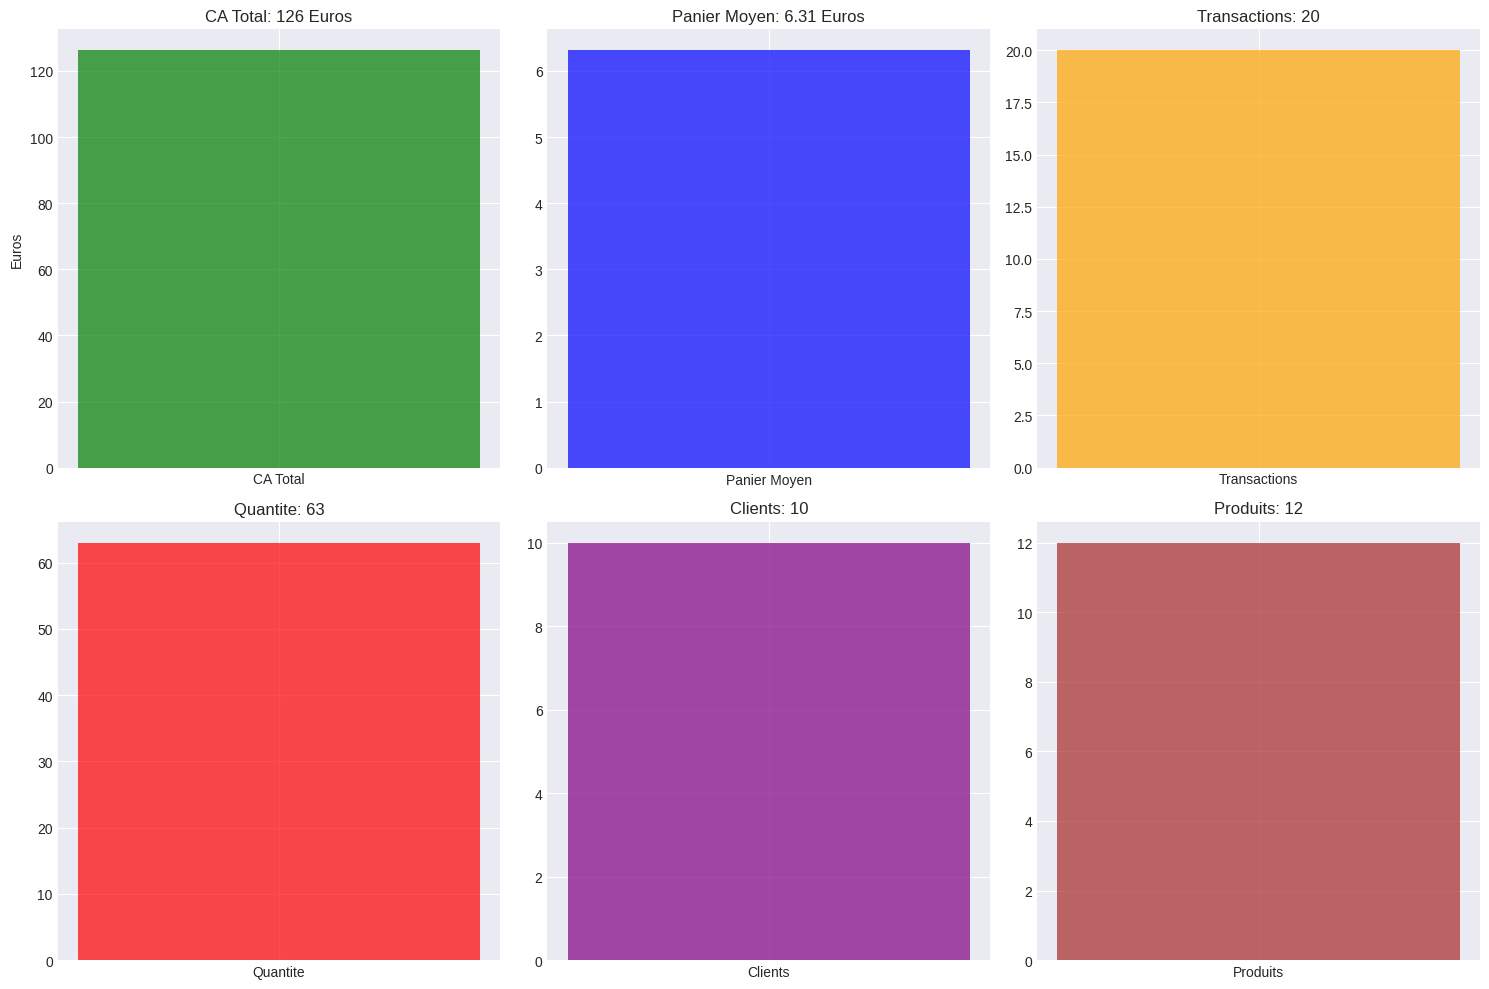

In [5]:
if 'df' in locals():
    print("CALCUL DES INDICATEURS CLES DE PERFORMANCE")
    print("-" * 50)
    
    ca_total = df['montant_ttc'].sum()
    nb_transactions = len(df)
    panier_moyen = df['montant_ttc'].mean()
    quantite_totale = df['quantite'].sum()
    nb_clients = df['id_client'].nunique() if 'id_client' in df.columns else 0
    nb_produits = df['id_produit'].nunique() if 'id_produit' in df.columns else 0
    nb_magasins = df['id_magasin'].nunique() if 'id_magasin' in df.columns else 0
    ca_min = df['montant_ttc'].min()
    ca_max = df['montant_ttc'].max()
    ca_std = df['montant_ttc'].std()
    
    kpis = pd.DataFrame({
        'Indicateur': [
            'Chiffre d Affaires Total',
            'Nombre de Transactions',
            'Panier Moyen',
            'Quantite Totale Vendue',
            'Nombre de Clients Uniques',
            'Nombre de Produits Uniques',
            'Nombre de Magasins',
            'Vente Minimum',
            'Vente Maximum',
            'Ecart Type des Ventes'
        ],
        'Valeur': [
            f"{ca_total:.2f} Euros",
            f"{nb_transactions}",
            f"{panier_moyen:.2f} Euros",
            f"{quantite_totale}",
            f"{nb_clients}",
            f"{nb_produits}",
            f"{nb_magasins}",
            f"{ca_min:.2f} Euros",
            f"{ca_max:.2f} Euros",
            f"{ca_std:.2f} Euros"
        ]
    })
    
    display(kpis)
    
    print("\nVisualisation des KPIs")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0,0].bar(['CA Total'], [ca_total], color='green', alpha=0.7)
    axes[0,0].set_title(f'CA Total: {ca_total:.0f} Euros')
    axes[0,0].set_ylabel('Euros')
    
    axes[0,1].bar(['Panier Moyen'], [panier_moyen], color='blue', alpha=0.7)
    axes[0,1].set_title(f'Panier Moyen: {panier_moyen:.2f} Euros')
    
    axes[0,2].bar(['Transactions'], [nb_transactions], color='orange', alpha=0.7)
    axes[0,2].set_title(f'Transactions: {nb_transactions}')
    
    axes[1,0].bar(['Quantite'], [quantite_totale], color='red', alpha=0.7)
    axes[1,0].set_title(f'Quantite: {quantite_totale}')
    
    axes[1,1].bar(['Clients'], [nb_clients], color='purple', alpha=0.7)
    axes[1,1].set_title(f'Clients: {nb_clients}')
    
    axes[1,2].bar(['Produits'], [nb_produits], color='brown', alpha=0.7)
    axes[1,2].set_title(f'Produits: {nb_produits}')
    
    plt.tight_layout()
    plt.show()

ANALYSE DES PRODUITS
--------------------------------------------------
TOP 10 PRODUITS PAR CHIFFRE D AFFAIRES


,montant_ttc,quantite,nb_ventes,part_ca
nom_produit,,,,
Coca-Cola 2L,23.80,9,2,18.85
Lessive liquide 3L,14.88,3,2,11.78
Eau minerale 6x1.5L,14.41,5,2,11.41
Essuie-tout x4,13.80,6,1,10.93
Pates 500g,11.05,13,2,8.75
Jus d orange 1L,10.50,5,2,8.32
Shampoing 250ml,7.80,2,2,6.18
Dentifrice 75ml,7.50,3,1,5.94
Pain de mie 500g,7.20,6,2,5.70


TOP 10 PRODUITS PAR QUANTITE VENDUE


,montant_ttc,quantite,nb_ventes,part_ca
nom_produit,,,,
Pates 500g,11.05,13,2,8.75
Coca-Cola 2L,23.80,9,2,18.85
Lait entier 1L,6.66,7,2,5.27
Essuie-tout x4,13.80,6,1,10.93
Pain de mie 500g,7.20,6,2,5.70
Eau minerale 6x1.5L,14.41,5,2,11.41
Jus d orange 1L,10.50,5,2,8.32
Lessive liquide 3L,14.88,3,2,11.78
Dentifrice 75ml,7.50,3,1,5.94


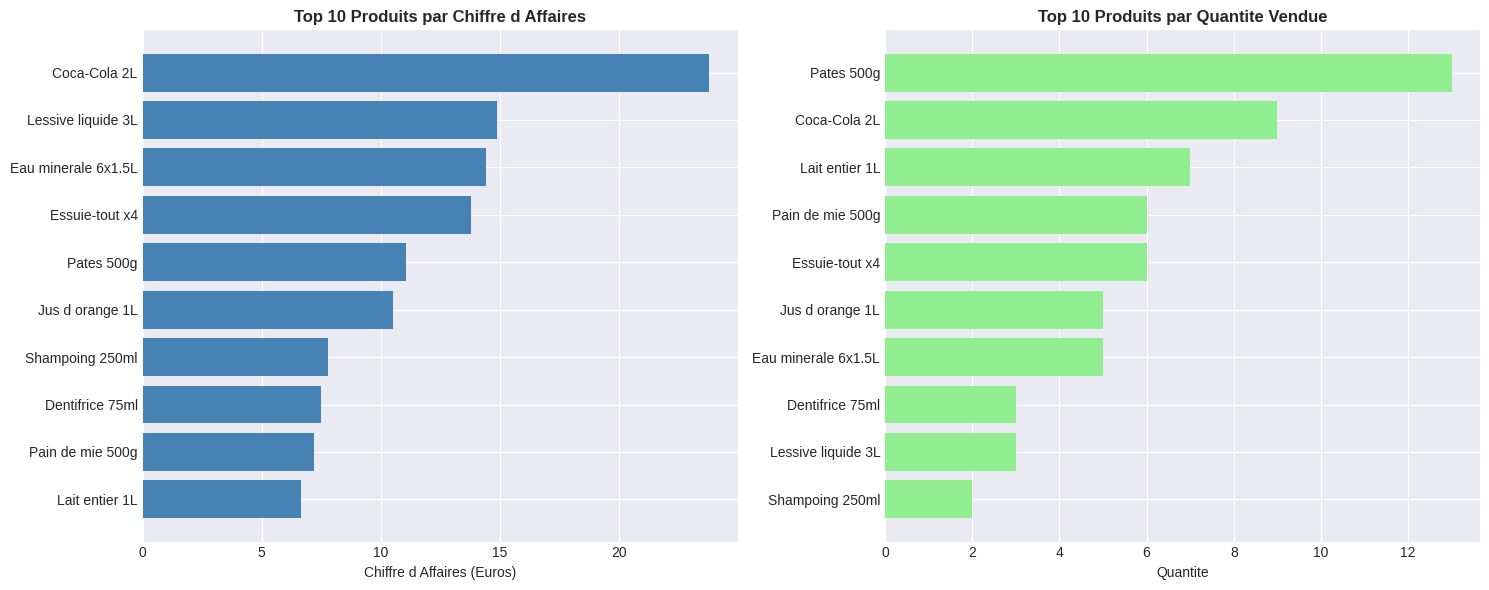

In [6]:
if 'df' in locals() and 'nom_produit' in df.columns:
    print("ANALYSE DES PRODUITS")
    print("-" * 50)
    
    top_produits = df.groupby('nom_produit').agg({
        'montant_ttc': 'sum',
        'quantite': 'sum',
        'id_vente': 'count'
    }).rename(columns={'id_vente': 'nb_ventes'})
    
    top_produits['part_ca'] = (top_produits['montant_ttc'] / top_produits['montant_ttc'].sum() * 100).round(2)
    top_produits = top_produits.sort_values('montant_ttc', ascending=False)
    
    print("TOP 10 PRODUITS PAR CHIFFRE D AFFAIRES")
    display(top_produits.head(10))
    
    print("TOP 10 PRODUITS PAR QUANTITE VENDUE")
    display(top_produits.sort_values('quantite', ascending=False).head(10))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    top10_ca = top_produits.head(10).sort_values('montant_ttc')
    ax1.barh(top10_ca.index, top10_ca['montant_ttc'], color='steelblue')
    ax1.set_title('Top 10 Produits par Chiffre d Affaires', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Chiffre d Affaires (Euros)')
    
    top10_qte = top_produits.head(10).sort_values('quantite')
    ax2.barh(top10_qte.index, top10_qte['quantite'], color='lightgreen')
    ax2.set_title('Top 10 Produits par Quantite Vendue', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Quantite')
    
    plt.tight_layout()
    plt.show()

ANALYSE PAR CATEGORIE DE PRODUITS
--------------------------------------------------


,Chiffre d Affaires (Euros),Pourcentage du CA
nom_categorie,,
Boissons,48.71,38.58
Entretien Maison,28.68,22.71
Alimentation,18.66,14.78
Hygiene Beaute,15.30,12.12
Epicerie Seche,14.92,11.82


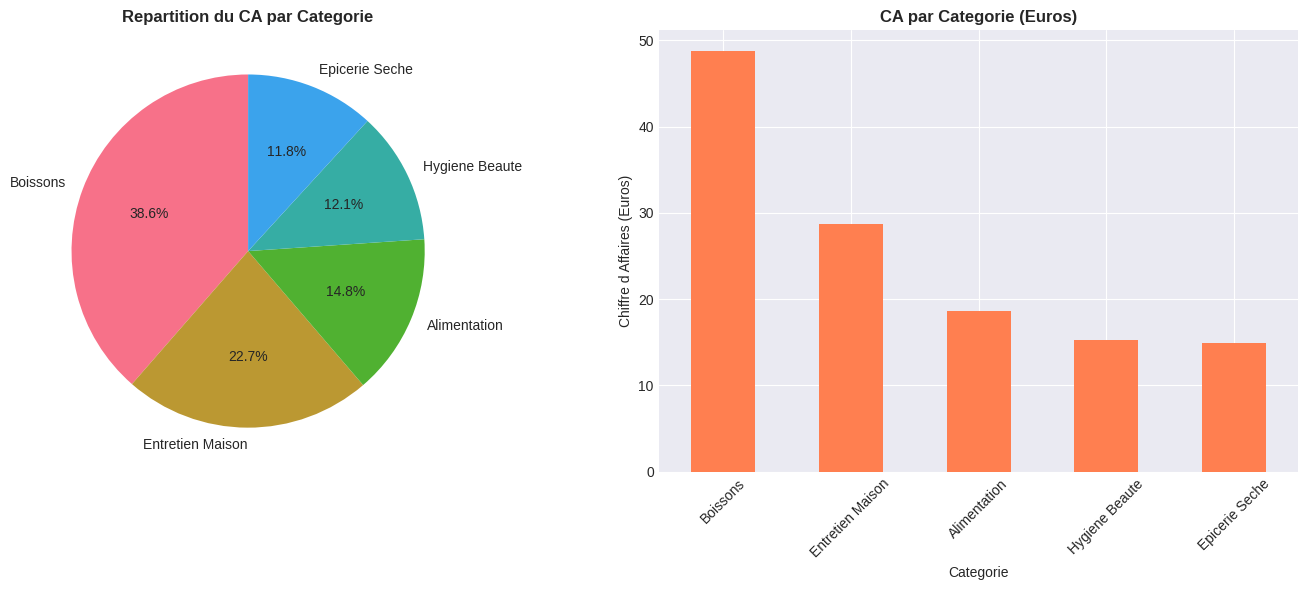

In [7]:
if 'df' in locals() and 'nom_categorie' in df.columns:
    print("ANALYSE PAR CATEGORIE DE PRODUITS")
    print("-" * 50)
    
    ca_categorie = df.groupby('nom_categorie')['montant_ttc'].sum().sort_values(ascending=False)
    pct_categorie = (ca_categorie / ca_categorie.sum() * 100).round(2)
    
    categorie_stats = pd.DataFrame({
        'Chiffre d Affaires (Euros)': ca_categorie,
        'Pourcentage du CA': pct_categorie
    })
    
    display(categorie_stats)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.pie(ca_categorie, labels=ca_categorie.index, autopct='%1.1f%%', startangle=90)
    ax1.set_title('Repartition du CA par Categorie', fontsize=12, fontweight='bold')
    
    ca_categorie.plot(kind='bar', ax=ax2, color='coral')
    ax2.set_title('CA par Categorie (Euros)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Categorie')
    ax2.set_ylabel('Chiffre d Affaires (Euros)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

ANALYSE TEMPORELLE COMPLETE DES VENTES

1. ANALYSE PAR SEMAINE
----------------------------------------
Ventes par semaine:


CA_Total  CA_Moyen  Nb_Ventes  Quantite_Totale
annee semaine_num                                                
2024  1               25.40      6.35          4               15
      2                3.90      3.90          1                1
      5                4.25      4.25          1                5
      8                2.40      2.40          1                2
      11               6.20      6.20          1                1
      15               6.30      6.30          1                3
      21               4.80      4.80          1                2
      26              11.20     11.20          1                4
      28               3.87      3.87          1                2
      31               7.50      7.50          1                3


Top 5 meilleures semaines:


CA_Total  CA_Moyen  Nb_Ventes  Quantite_Totale
annee semaine_num                                                
2024  1               25.40      6.35          4               15
      52              16.50      8.25          2                6
      37              13.80     13.80          1                6
      46              12.15      6.07          2                7
      26              11.20     11.20          1                4

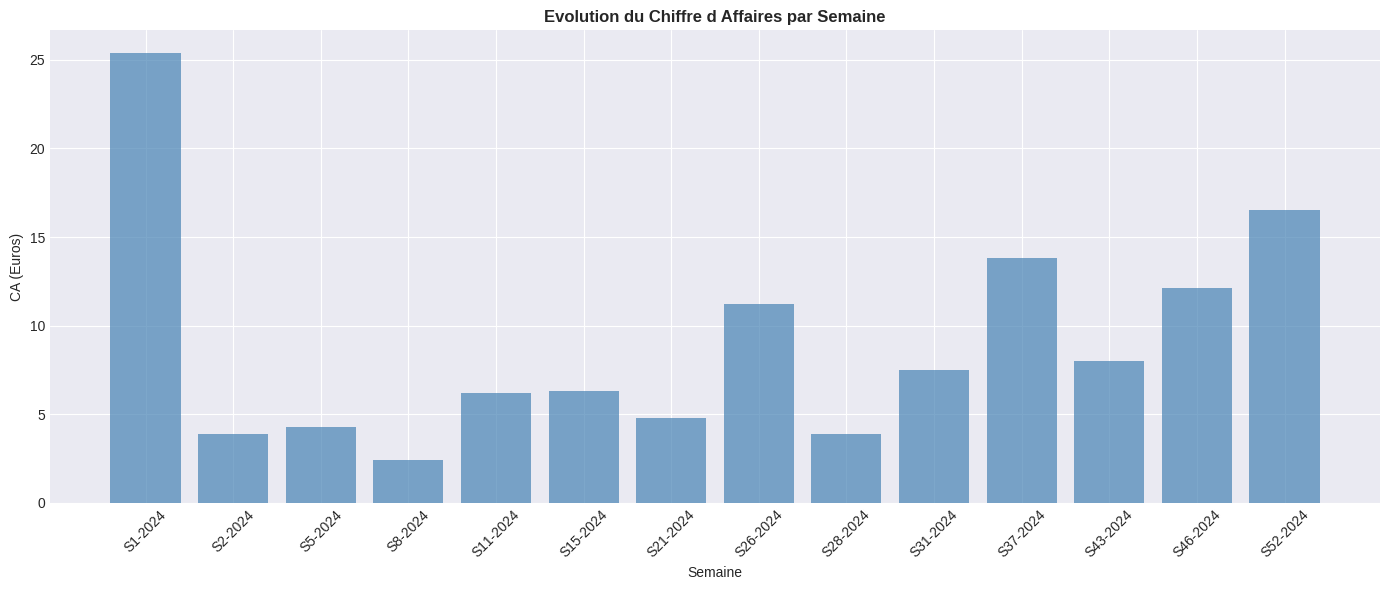


2. ANALYSE PAR MOIS
----------------------------------------
Ventes par mois:


CA_Total  CA_Moyen  CA_Std  Nb_Ventes  \
annee mois_num mois_nom                                           
2024  1        January       13.82      4.61    2.19          3   
      2        February       6.65      3.32    1.31          2   
      3        March          6.20      6.20     NaN          1   
      4        April          6.30      6.30     NaN          1   
      5        May            4.80      4.80     NaN          1   
      6        June          11.20     11.20     NaN          1   
      7        July           3.87      3.87     NaN          1   
      8        August         7.50      7.50     NaN          1   
      9        September     13.80     13.80     NaN          1   
      10       October        8.00      4.00    0.28          2   
      11       November      12.15      6.07    1.80          2   
      12       December      31.98      8.00    3.65          4   

                          Quantite_Totale  
annee mois_num mois_nom                    
2024  1        January                  6  
      2        February                 7  
      3        March                    1  
      4        April                    3  
      5        May                      2  
      6        June                     4  
      7        July                     2  
      8        August                   3  
      9        September                6  
      10       October                  6  
      11       November                 7  
      12       December                16


CA moyen par mois: 10.52 Euros
Meilleur mois: CA = 31.98 Euros


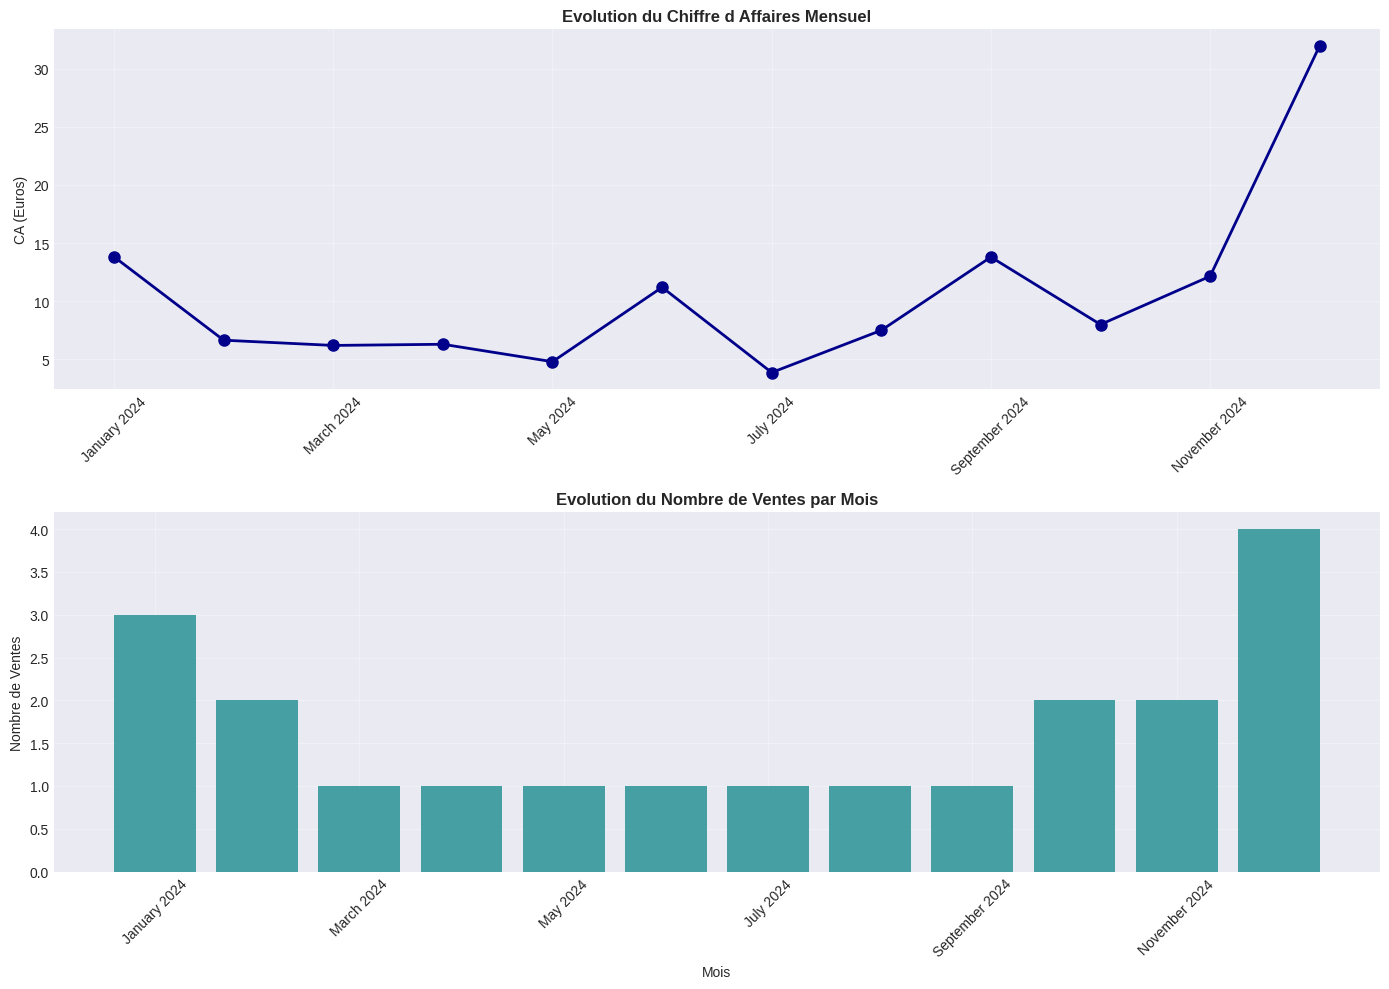


3. ANALYSE PAR TRIMESTRE
----------------------------------------
Ventes par trimestre:


CA_Total  CA_Moyen  Nb_Ventes  Quantite_Totale
annee trimestre                                                
2024  1             26.67      4.44          6               14
      2             22.30      7.43          3                9
      3             25.17      8.39          3               11
      4             52.13      6.52          8               29

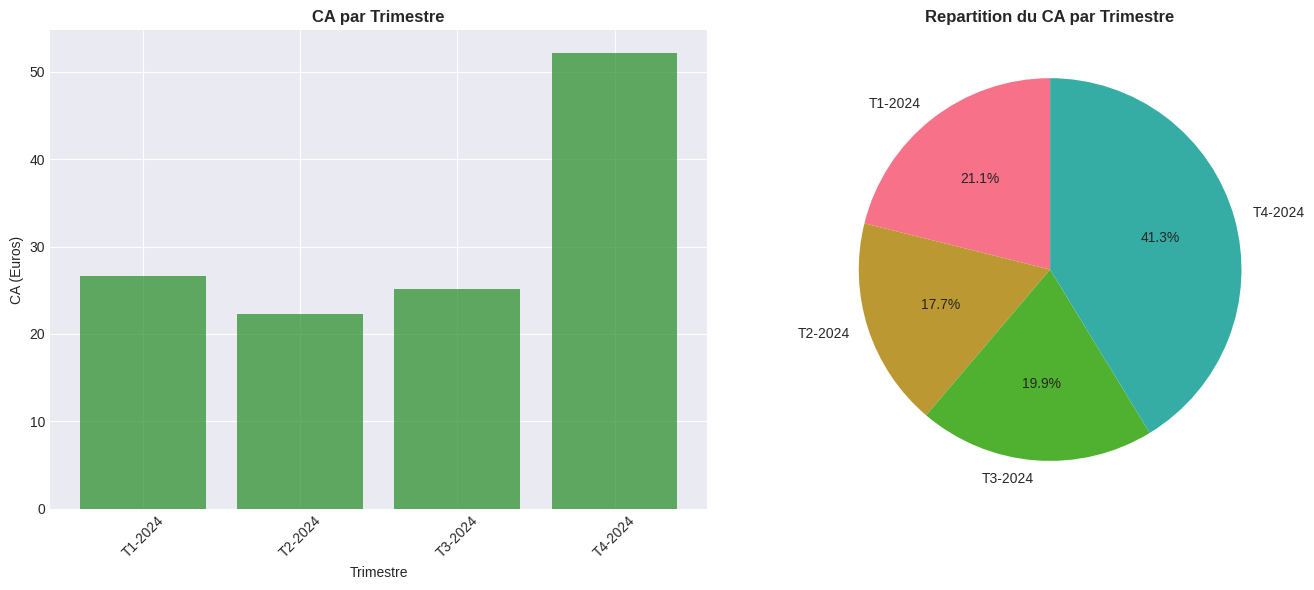


4. ANALYSE PAR SEMESTRE
----------------------------------------
Ventes par semestre:


CA_Total  CA_Moyen  Nb_Ventes  Quantite_Totale
annee semestre                                                
2024  1            48.97      5.44          9               23
      2            77.30      7.03         11               40

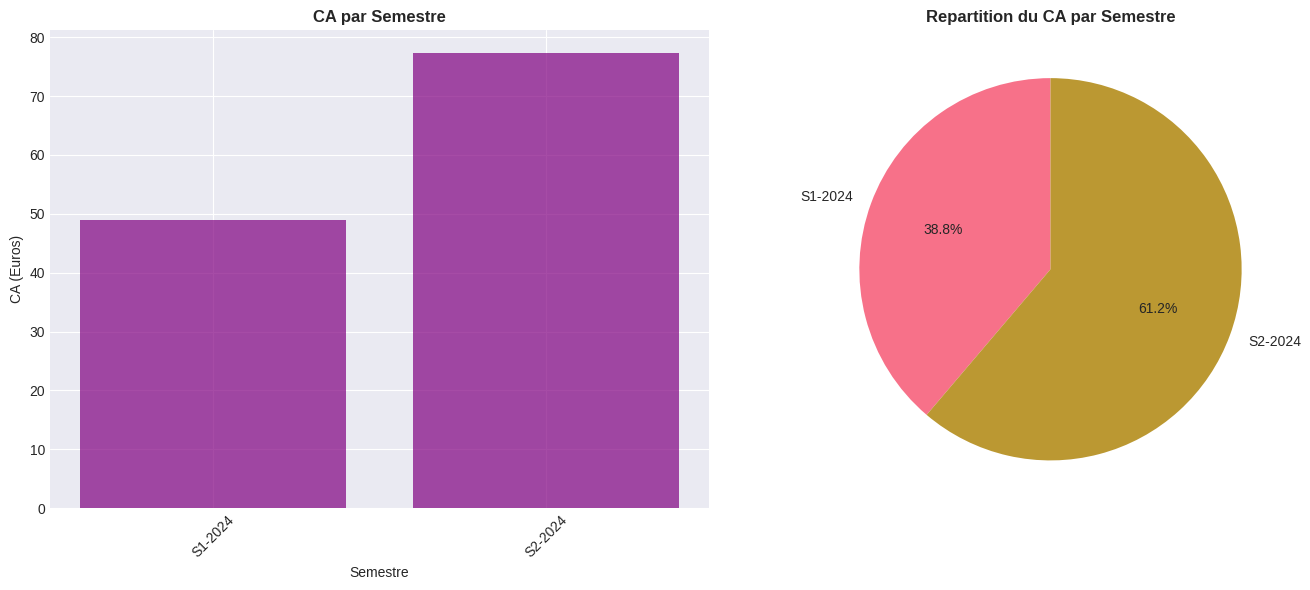


5. ANALYSE PAR ANNEE
----------------------------------------
Ventes par annee:


,CA_Total,CA_Moyen,Nb_Ventes,Quantite_Totale
annee,,,,
2024,126.27,6.31,20,63


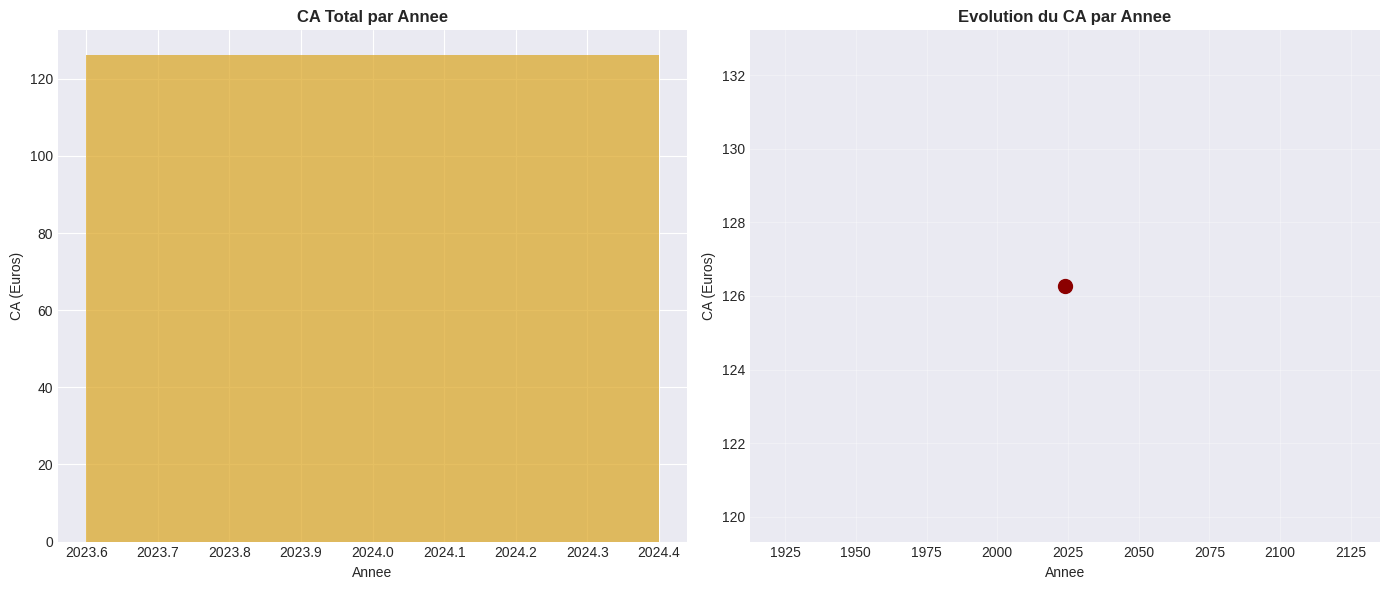


6. ANALYSE PAR JOUR DE SEMAINE
----------------------------------------
Ventes par jour de semaine:


,CA_Total,CA_Moyen,Nb_Ventes,Quantite_Totale
jour_semaine,,,,
Monday,25.95,8.65,3,13
Tuesday,34.38,6.88,5,18
Wednesday,11.10,5.55,2,5
Thursday,7.50,7.50,1,3
Friday,28.02,4.67,6,13
Saturday,4.25,4.25,1,5
Sunday,15.07,7.54,2,6



Meilleur jour de vente: Tuesday


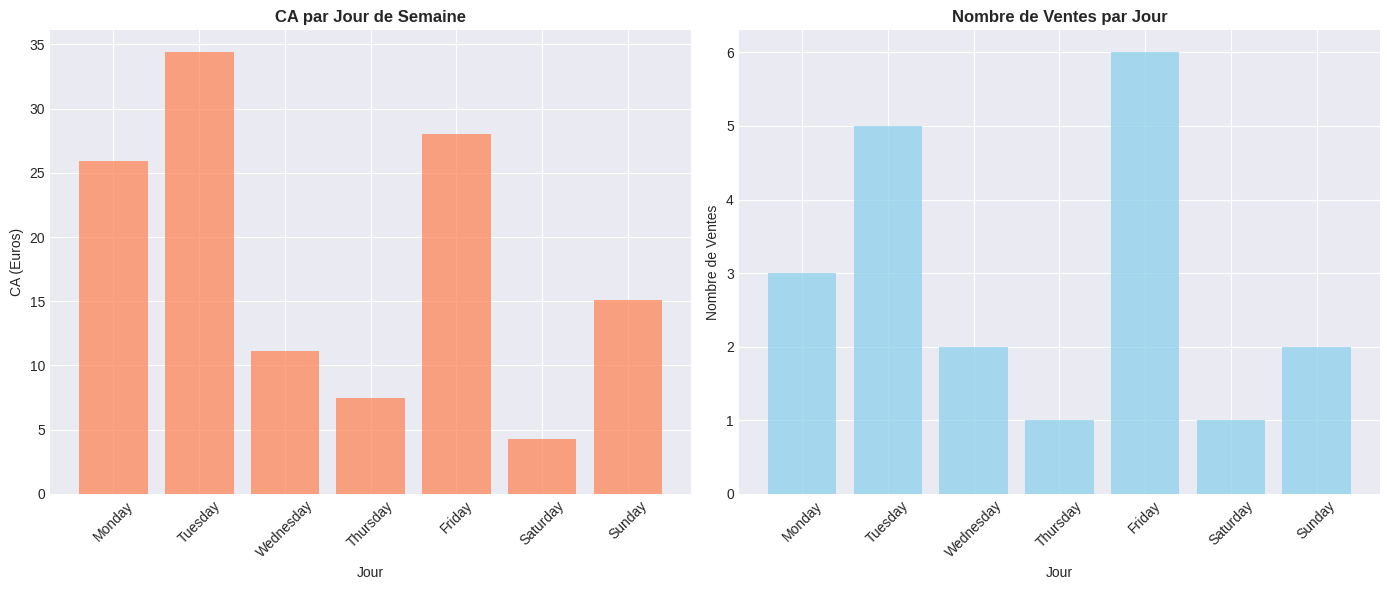


7. TABLEAU RECAPITULATIF DES PERFORMANCES


,Periode,CA_Total (Euros),CA_Moyen (Euros),Nb_Ventes_Total
0,Hebdomadaire,126.27,9.02,20
1,Mensuelle,126.27,10.52,20
2,Trimestrielle,126.27,31.57,20
3,Semestrielle,126.27,63.14,20
4,Annuelle,126.27,126.27,20


In [50]:
if 'df' in locals() and 'date_complete' in df.columns:
    print("ANALYSE TEMPORELLE COMPLETE DES VENTES")
    print("=" * 60)
    
    # S'assurer que la colonne date est au bon format
    df['date_complete'] = pd.to_datetime(df['date_complete'])
    
    # Creer les colonnes temporelles
    df['annee'] = df['date_complete'].dt.year
    df['mois_num'] = df['date_complete'].dt.month
    df['mois_nom'] = df['date_complete'].dt.strftime('%B')
    df['semaine_num'] = df['date_complete'].dt.isocalendar().week
    df['trimestre'] = df['date_complete'].dt.quarter
    df['semestre'] = df['date_complete'].dt.month.apply(lambda x: 1 if x <= 6 else 2)
    df['jour_semaine'] = df['date_complete'].dt.day_name()
    df['mois_annee'] = df['date_complete'].dt.strftime('%Y-%m')
    
    # Ordre des jours
    ordre_jours = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    ordre_mois = ['January', 'February', 'March', 'April', 'May', 'June', 
                  'July', 'August', 'September', 'October', 'November', 'December']
    
    # ============================================
    # 1. ANALYSE PAR SEMAINE
    # ============================================
    print("\n1. ANALYSE PAR SEMAINE")
    print("-" * 40)
    
    ventes_semaine = df.groupby(['annee', 'semaine_num']).agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    ventes_semaine.columns = ['CA_Total', 'CA_Moyen', 'Nb_Ventes', 'Quantite_Totale']
    ventes_semaine = ventes_semaine.sort_index()
    
    print("Ventes par semaine:")
    display(ventes_semaine.head(10))
    
    # Top 5 meilleures semaines
    top_semaines = ventes_semaine.sort_values('CA_Total', ascending=False).head(5)
    print("\nTop 5 meilleures semaines:")
    display(top_semaines)
    
    # Graphique par semaine
    fig, ax = plt.subplots(figsize=(14, 6))
    semaines_labels = [f"S{row[1]}-{row[0]}" for row in ventes_semaine.index]
    ax.bar(range(len(ventes_semaine)), ventes_semaine['CA_Total'], color='steelblue', alpha=0.7)
    ax.set_xlabel('Semaine')
    ax.set_ylabel('CA (Euros)')
    ax.set_title('Evolution du Chiffre d Affaires par Semaine', fontsize=12, fontweight='bold')
    ax.set_xticks(range(0, len(ventes_semaine), max(1, len(ventes_semaine)//10)))
    ax.set_xticklabels([semaines_labels[i] for i in range(0, len(ventes_semaine), max(1, len(ventes_semaine)//10))], rotation=45)
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 2. ANALYSE PAR MOIS
    # ============================================
    print("\n2. ANALYSE PAR MOIS")
    print("-" * 40)
    
    ventes_mois = df.groupby(['annee', 'mois_num', 'mois_nom']).agg({
        'montant_ttc': ['sum', 'mean', 'std'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    ventes_mois.columns = ['CA_Total', 'CA_Moyen', 'CA_Std', 'Nb_Ventes', 'Quantite_Totale']
    ventes_mois = ventes_mois.sort_index()
    
    print("Ventes par mois:")
    display(ventes_mois)
    
    # Moyenne mensuelle
    ca_moyen_mensuel = ventes_mois['CA_Total'].mean()
    print(f"\nCA moyen par mois: {ca_moyen_mensuel:.2f} Euros")
    
    # Meilleur mois
    meilleur_mois = ventes_mois.loc[ventes_mois['CA_Total'].idxmax()]
    print(f"Meilleur mois: CA = {meilleur_mois['CA_Total']:.2f} Euros")
    
    # Graphique par mois
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    mois_labels = [f"{row[2]} {row[0]}" for row in ventes_mois.index]
    
    axes[0].plot(range(len(ventes_mois)), ventes_mois['CA_Total'], marker='o', linewidth=2, markersize=8, color='darkblue')
    axes[0].set_title('Evolution du Chiffre d Affaires Mensuel', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('CA (Euros)')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(range(0, len(ventes_mois), max(1, len(ventes_mois)//6)))
    axes[0].set_xticklabels([mois_labels[i] for i in range(0, len(ventes_mois), max(1, len(ventes_mois)//6))], rotation=45)
    
    axes[1].bar(range(len(ventes_mois)), ventes_mois['Nb_Ventes'], color='teal', alpha=0.7)
    axes[1].set_title('Evolution du Nombre de Ventes par Mois', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Mois')
    axes[1].set_ylabel('Nombre de Ventes')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(range(0, len(ventes_mois), max(1, len(ventes_mois)//6)))
    axes[1].set_xticklabels([mois_labels[i] for i in range(0, len(ventes_mois), max(1, len(ventes_mois)//6))], rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 3. ANALYSE PAR TRIMESTRE
    # ============================================
    print("\n3. ANALYSE PAR TRIMESTRE")
    print("-" * 40)
    
    ventes_trimestre = df.groupby(['annee', 'trimestre']).agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    ventes_trimestre.columns = ['CA_Total', 'CA_Moyen', 'Nb_Ventes', 'Quantite_Totale']
    ventes_trimestre = ventes_trimestre.sort_index()
    
    print("Ventes par trimestre:")
    display(ventes_trimestre)
    
    # Graphique par trimestre
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    trimestre_labels = [f"T{row[1]}-{row[0]}" for row in ventes_trimestre.index]
    
    ax1.bar(range(len(ventes_trimestre)), ventes_trimestre['CA_Total'], color='forestgreen', alpha=0.7)
    ax1.set_xlabel('Trimestre')
    ax1.set_ylabel('CA (Euros)')
    ax1.set_title('CA par Trimestre', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(len(ventes_trimestre)))
    ax1.set_xticklabels(trimestre_labels, rotation=45)
    
    ax2.pie(ventes_trimestre['CA_Total'], labels=trimestre_labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Repartition du CA par Trimestre', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 4. ANALYSE PAR SEMESTRE
    # ============================================
    print("\n4. ANALYSE PAR SEMESTRE")
    print("-" * 40)
    
    ventes_semestre = df.groupby(['annee', 'semestre']).agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    ventes_semestre.columns = ['CA_Total', 'CA_Moyen', 'Nb_Ventes', 'Quantite_Totale']
    ventes_semestre = ventes_semestre.sort_index()
    
    print("Ventes par semestre:")
    display(ventes_semestre)
    
    # Graphique par semestre
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    semestre_labels = [f"S{row[1]}-{row[0]}" for row in ventes_semestre.index]
    
    ax1.bar(range(len(ventes_semestre)), ventes_semestre['CA_Total'], color='purple', alpha=0.7)
    ax1.set_xlabel('Semestre')
    ax1.set_ylabel('CA (Euros)')
    ax1.set_title('CA par Semestre', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(len(ventes_semestre)))
    ax1.set_xticklabels(semestre_labels, rotation=45)
    
    ax2.pie(ventes_semestre['CA_Total'], labels=semestre_labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Repartition du CA par Semestre', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 5. ANALYSE PAR ANNEE
    # ============================================
    print("\n5. ANALYSE PAR ANNEE")
    print("-" * 40)
    
    ventes_annee = df.groupby('annee').agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    ventes_annee.columns = ['CA_Total', 'CA_Moyen', 'Nb_Ventes', 'Quantite_Totale']
    
    print("Ventes par annee:")
    display(ventes_annee)
    
    # Calcul des variations annuelles
    if len(ventes_annee) > 1:
        annees = ventes_annee.index.tolist()
        variations = []
        for i in range(1, len(annees)):
            var = ((ventes_annee['CA_Total'].iloc[i] - ventes_annee['CA_Total'].iloc[i-1]) / ventes_annee['CA_Total'].iloc[i-1] * 100)
            variations.append(var)
        
        print("\nVariations annuelles:")
        for i, var in enumerate(variations):
            print(f"  {annees[i]} -> {annees[i+1]}: {var:.1f}%")
    
    # Graphique par annee
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].bar(ventes_annee.index, ventes_annee['CA_Total'], color='goldenrod', alpha=0.7)
    axes[0].set_xlabel('Annee')
    axes[0].set_ylabel('CA (Euros)')
    axes[0].set_title('CA Total par Annee', fontsize=12, fontweight='bold')
    
    axes[1].plot(ventes_annee.index, ventes_annee['CA_Total'], marker='o', linewidth=2, markersize=10, color='darkred')
    axes[1].set_xlabel('Annee')
    axes[1].set_ylabel('CA (Euros)')
    axes[1].set_title('Evolution du CA par Annee', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 6. ANALYSE PAR JOUR DE SEMAINE
    # ============================================
    print("\n6. ANALYSE PAR JOUR DE SEMAINE")
    print("-" * 40)
    
    ventes_jour = df.groupby('jour_semaine').agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    ventes_jour.columns = ['CA_Total', 'CA_Moyen', 'Nb_Ventes', 'Quantite_Totale']
    ventes_jour = ventes_jour.reindex(ordre_jours)
    
    print("Ventes par jour de semaine:")
    display(ventes_jour)
    
    # Meilleur jour
    meilleur_jour = ventes_jour['CA_Total'].idxmax()
    print(f"\nMeilleur jour de vente: {meilleur_jour}")
    
    # Graphique par jour
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].bar(ventes_jour.index, ventes_jour['CA_Total'], color='coral', alpha=0.7)
    axes[0].set_xlabel('Jour')
    axes[0].set_ylabel('CA (Euros)')
    axes[0].set_title('CA par Jour de Semaine', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    
    axes[1].bar(ventes_jour.index, ventes_jour['Nb_Ventes'], color='skyblue', alpha=0.7)
    axes[1].set_xlabel('Jour')
    axes[1].set_ylabel('Nombre de Ventes')
    axes[1].set_title('Nombre de Ventes par Jour', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================
    # 7. TABLEAU RECAPITULATIF
    # ============================================
    print("\n7. TABLEAU RECAPITULATIF DES PERFORMANCES")
    print("=" * 60)
    
    recap = pd.DataFrame({
        'Periode': ['Hebdomadaire', 'Mensuelle', 'Trimestrielle', 'Semestrielle', 'Annuelle'],
        'CA_Total (Euros)': [
            ventes_semaine['CA_Total'].sum(),
            ventes_mois['CA_Total'].sum(),
            ventes_trimestre['CA_Total'].sum(),
            ventes_semestre['CA_Total'].sum(),
            ventes_annee['CA_Total'].sum()
        ],
        'CA_Moyen (Euros)': [
            ventes_semaine['CA_Total'].mean(),
            ventes_mois['CA_Total'].mean(),
            ventes_trimestre['CA_Total'].mean(),
            ventes_semestre['CA_Total'].mean(),
            ventes_annee['CA_Total'].mean()
        ],
        'Nb_Ventes_Total': [
            ventes_semaine['Nb_Ventes'].sum(),
            ventes_mois['Nb_Ventes'].sum(),
            ventes_trimestre['Nb_Ventes'].sum(),
            ventes_semestre['Nb_Ventes'].sum(),
            ventes_annee['Nb_Ventes'].sum()
        ]
    }).round(2)
    
    display(recap)
    
   
   



ANALYSE DES MAGASINS
--------------------------------------------------
Utilisation de la colonne: nom_magasin_x
Magasins trouves: ['Supermarche A - Centre', 'Supermarche A - Nord', 'Supermarche A - Sud', 'Supermarche A - Est']

PERFORMANCE PAR MAGASIN


,CA_Total,Panier_Moyen,Nb_Ventes,Quantite_Totale,Nb_Clients,CA_par_Client
nom_magasin_x,,,,,,
Supermarche A - Sud,43.10,8.62,5,17,5,8.62
Supermarche A - Centre,35.90,5.13,7,18,5,7.18
Supermarche A - Nord,32.00,6.40,5,22,4,8.00
Supermarche A - Est,15.27,5.09,3,6,3,5.09


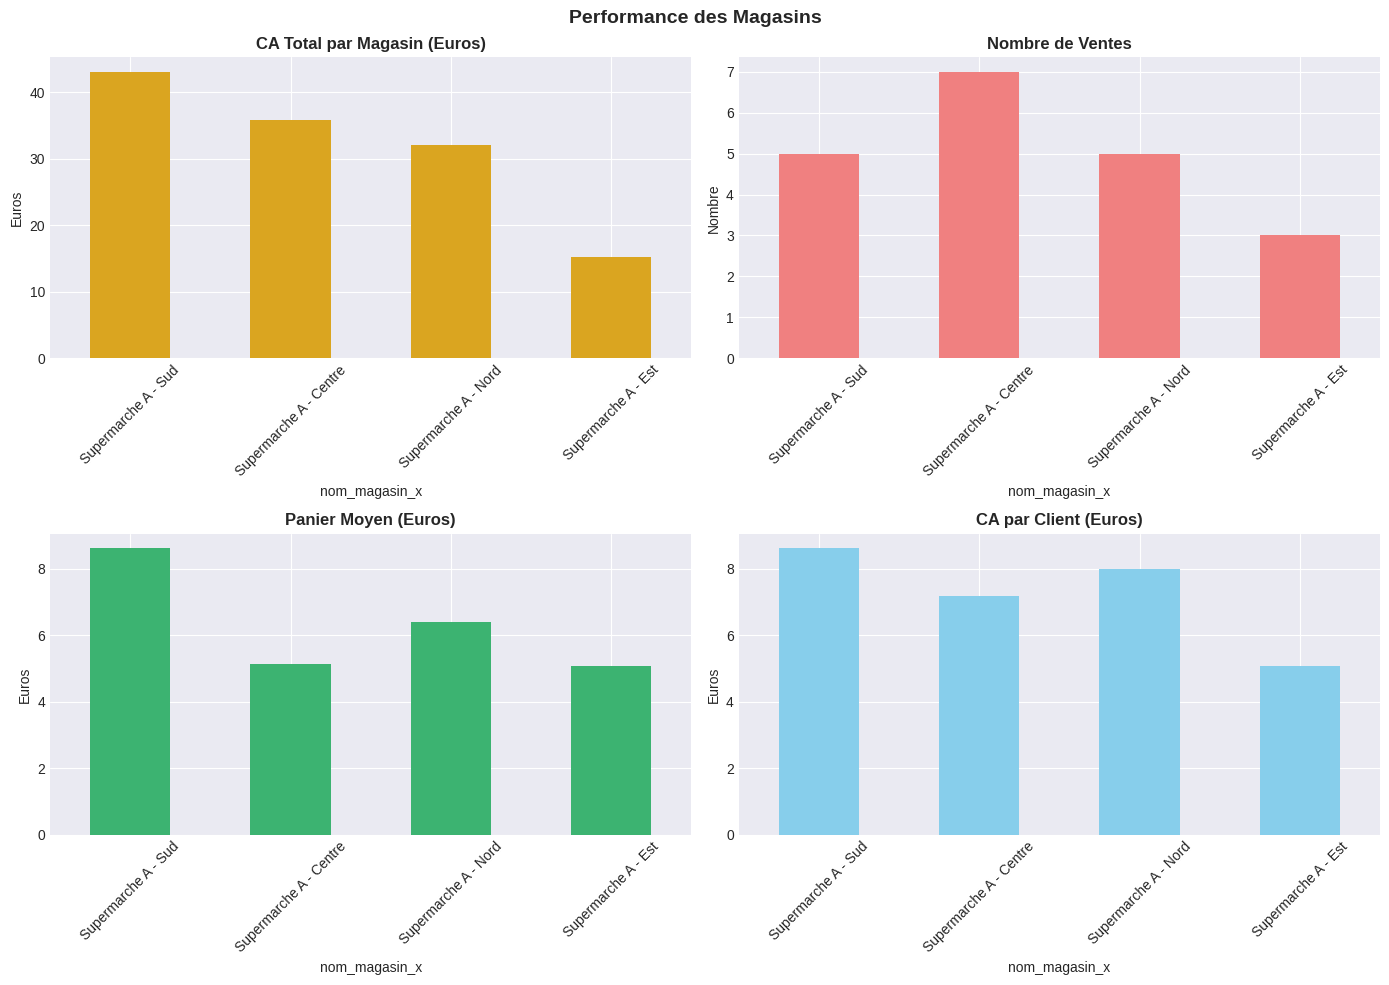


PERFORMANCE PAR VILLE
--------------------------------------------------
Utilisation de la colonne: ville_x
         CA_Total  Quantite_Totale  Nb_Magasins  Nb_Clients  CA_par_Client
ville_x                                                                   
Dakar       47.62               22            3           4          11.90
Abidjan     42.60               23            3           3          14.20
Bamako      36.05               18            4           3          12.02


,CA_Total,Quantite_Totale,Nb_Magasins,Nb_Clients,CA_par_Client
ville_x,,,,,
Dakar,47.62,22,3,4,11.90
Abidjan,42.60,23,3,3,14.20
Bamako,36.05,18,4,3,12.02


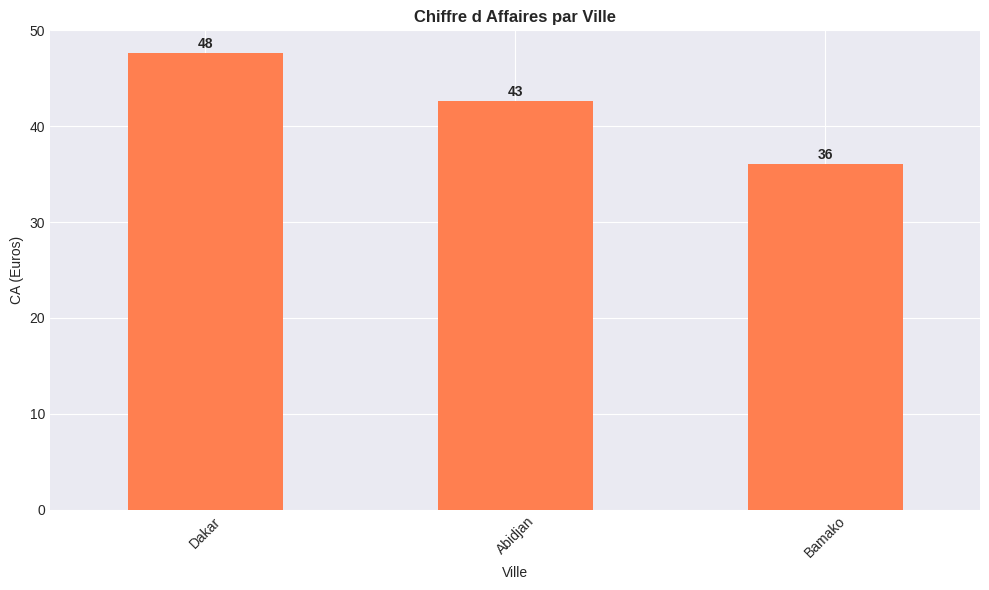

In [33]:
if 'df' in locals():
    print("ANALYSE DES MAGASINS")
    print("-" * 50)
    
    # Utiliser la bonne colonne pour les magasins
    colonne_magasin = 'nom_magasin_x' if 'nom_magasin_x' in df.columns else 'nom_magasin_y'
    
    print(f"Utilisation de la colonne: {colonne_magasin}")
    
    # Verifier les magasins uniques
    magasins_uniques = df[colonne_magasin].unique()
    print(f"Magasins trouves: {list(magasins_uniques)}")
    
    # Calcul des performances par magasin
    perf_magasin = df.groupby(colonne_magasin).agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum',
        'id_client': 'nunique'
    }).round(2)
    
    # Renommer les colonnes
    perf_magasin.columns = ['CA_Total', 'Panier_Moyen', 'Nb_Ventes', 'Quantite_Totale', 'Nb_Clients']
    perf_magasin['CA_par_Client'] = (perf_magasin['CA_Total'] / perf_magasin['Nb_Clients']).round(2)
    perf_magasin = perf_magasin.sort_values('CA_Total', ascending=False)
    
    print("\nPERFORMANCE PAR MAGASIN")
    display(perf_magasin)
    
    # Graphiques
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Performance des Magasins', fontsize=14, fontweight='bold')
    
    # CA Total
    perf_magasin['CA_Total'].plot(kind='bar', ax=axes[0,0], color='goldenrod')
    axes[0,0].set_title('CA Total par Magasin (Euros)', fontweight='bold')
    axes[0,0].set_ylabel('Euros')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Nombre de ventes
    perf_magasin['Nb_Ventes'].plot(kind='bar', ax=axes[0,1], color='lightcoral')
    axes[0,1].set_title('Nombre de Ventes', fontweight='bold')
    axes[0,1].set_ylabel('Nombre')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Panier moyen
    perf_magasin['Panier_Moyen'].plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
    axes[1,0].set_title('Panier Moyen (Euros)', fontweight='bold')
    axes[1,0].set_ylabel('Euros')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # CA par client
    perf_magasin['CA_par_Client'].plot(kind='bar', ax=axes[1,1], color='skyblue')
    axes[1,1].set_title('CA par Client (Euros)', fontweight='bold')
    axes[1,1].set_ylabel('Euros')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Analyse par ville
    print("\n" + "="*50)
    print("PERFORMANCE PAR VILLE")
    print("-" * 50)
    
    # Utiliser la bonne colonne pour la ville
    colonne_ville = 'ville_x' if 'ville_x' in df.columns else 'ville_y'
    print(f"Utilisation de la colonne: {colonne_ville}")
    
    perf_ville = df.groupby(colonne_ville).agg({
        'montant_ttc': 'sum',
        'quantite': 'sum',
        'id_magasin': 'nunique',
        'id_client': 'nunique'
    }).round(2)
    
    perf_ville.columns = ['CA_Total', 'Quantite_Totale', 'Nb_Magasins', 'Nb_Clients']
    perf_ville['CA_par_Client'] = (perf_ville['CA_Total'] / perf_ville['Nb_Clients']).round(2)
    perf_ville = perf_ville.sort_values('CA_Total', ascending=False)
    
    print(perf_ville)
    display(perf_ville)
    
    # Graphique par ville
    fig, ax = plt.subplots(figsize=(10, 6))
    perf_ville['CA_Total'].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Chiffre d Affaires par Ville', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ville')
    ax.set_ylabel('CA (Euros)')
    ax.tick_params(axis='x', rotation=45)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(perf_ville['CA_Total']):
        ax.text(i, v + 0.5, f'{v:.0f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

ANALYSE DES CLIENTS
--------------------------------------------------
SEGMENTATION DES CLIENTS


,CA_Total,CA_Moyen_Client,Nb_Achats_Total,Panier_Moyen
segment,,,,
Occasionnel Moins de 30 Euros,126.27,12.63,20,6.29



TOP 10 CLIENTS


,depense_totale,nb_achats,panier_moyen,segment
nom_client,,,,
Awa Diallo,23.72,3,7.906667,Occasionnel Moins de 30 Euros
Seydou Camara,16.00,2,8.000000,Occasionnel Moins de 30 Euros
Koffi Asante,15.00,2,7.500000,Occasionnel Moins de 30 Euros
Amina Kone,14.88,2,7.440000,Occasionnel Moins de 30 Euros
Ibrahim Bah,13.10,2,6.550000,Occasionnel Moins de 30 Euros
Fatima Ndiaye,11.60,2,5.800000,Occasionnel Moins de 30 Euros
Nadia Ouedraogo,8.70,2,4.350000,Occasionnel Moins de 30 Euros
Aissatou Barry,8.07,2,4.035000,Occasionnel Moins de 30 Euros
Moussa Traore,7.70,2,3.850000,Occasionnel Moins de 30 Euros


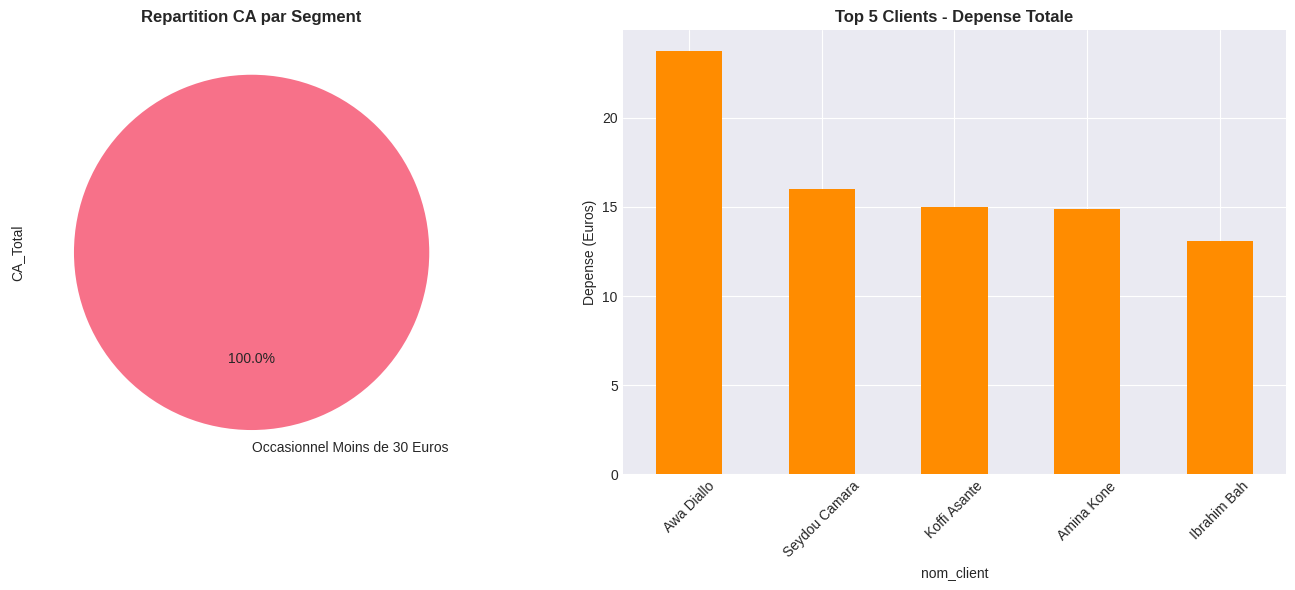

In [28]:
if 'df' in locals() and 'nom_client' in df.columns:
    print("ANALYSE DES CLIENTS")
    print("-" * 50)
    
    client_stats = df.groupby('nom_client').agg({
        'montant_ttc': 'sum',
        'id_vente': 'count',
        'quantite': 'sum'
    }).rename(columns={'montant_ttc': 'depense_totale', 'id_vente': 'nb_achats', 'quantite': 'quantite'})
    
    client_stats['panier_moyen'] = client_stats['depense_totale'] / client_stats['nb_achats']
    
    def segment_client(depense):
        if depense > 50:
            return 'VIP Plus de 50 Euros'
        elif depense > 30:
            return 'Regulier 30-50 Euros'
        else:
            return 'Occasionnel Moins de 30 Euros'
    
    client_stats['segment'] = client_stats['depense_totale'].apply(segment_client)
    
    segmentation = client_stats.groupby('segment').agg({
        'depense_totale': ['sum', 'mean'],
        'nb_achats': 'sum',
        'panier_moyen': 'mean'
    }).round(2)
    
    segmentation.columns = ['CA_Total', 'CA_Moyen_Client', 'Nb_Achats_Total', 'Panier_Moyen']
    
    print("SEGMENTATION DES CLIENTS")
    display(segmentation)
    
    print("\nTOP 10 CLIENTS")
    top_clients = client_stats.sort_values('depense_totale', ascending=False).head(10)
    display(top_clients[['depense_totale', 'nb_achats', 'panier_moyen', 'segment']])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    segmentation['CA_Total'].plot(kind='pie', autopct='%1.1f%%', ax=ax1, startangle=90)
    ax1.set_title('Repartition CA par Segment', fontsize=12, fontweight='bold')
    
    top_clients.head(5)['depense_totale'].plot(kind='bar', ax=ax2, color='darkorange')
    ax2.set_title('Top 5 Clients - Depense Totale', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Depense (Euros)')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

ANALYSE DES PROMOTIONS
--------------------------------------------------
COMPARAISON AVEC ET SANS PROMOTION


,CA_Total,Panier_Moyen,Nb_Ventes,Quantite_Totale
type_vente,,,,
Avec Promotion,58.60,5.86,10,25
Sans Promotion,67.67,6.77,10,38



PERFORMANCE PAR TYPE DE PROMOTION


,CA_Total,Nb_Ventes,Taux_Remise
nom_promo,,,
Black Friday,16.03,2,30.0
Fete des Meres,8.70,2,15.0
Promo Ete,26.67,4,10.0
Soldes Janvier,7.20,2,20.0


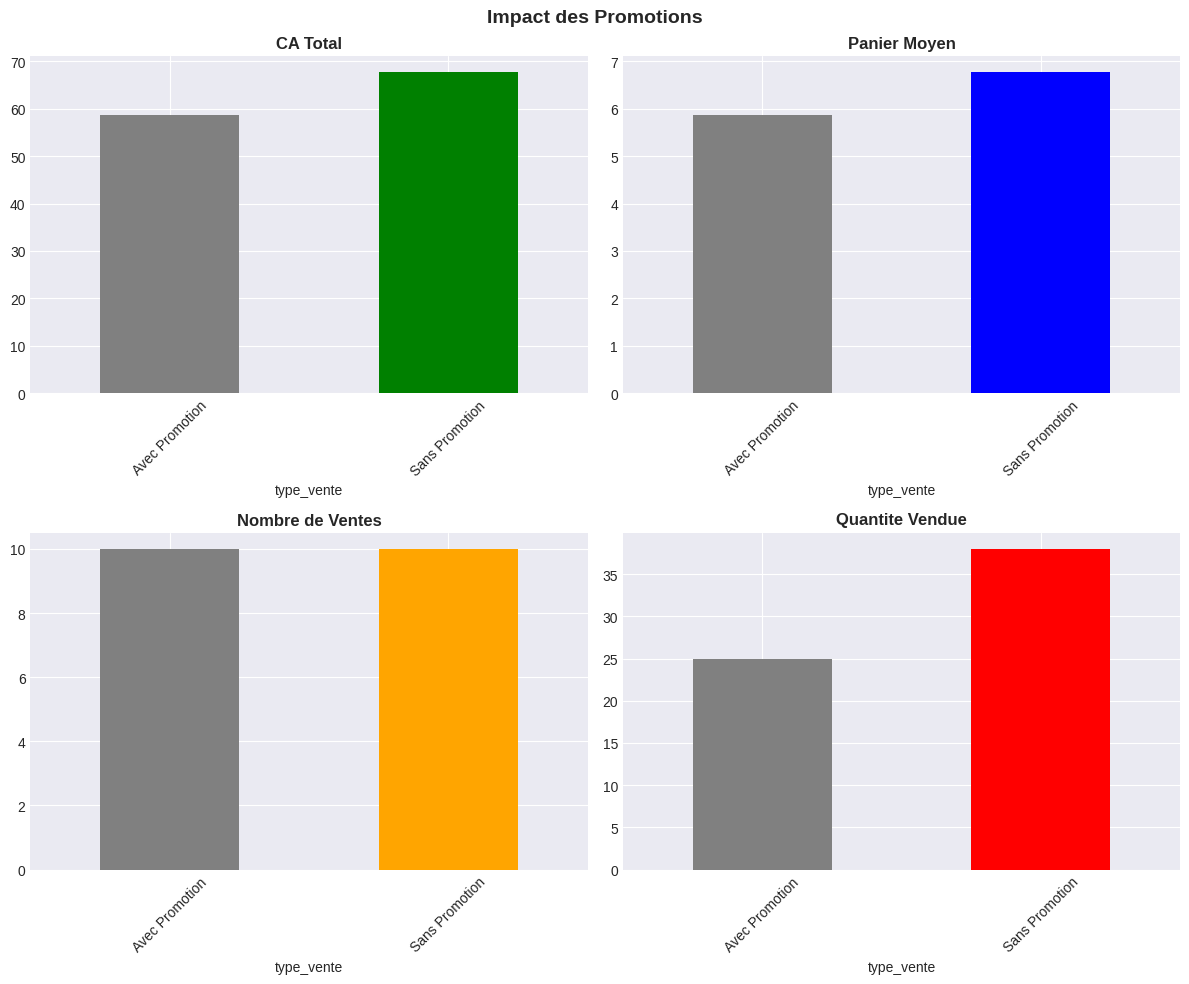


LIFT DES PROMOTIONS: +-13.4 pourcent sur le panier moyen


In [29]:
if 'df' in locals() and 'nom_promo' in df.columns:
    print("ANALYSE DES PROMOTIONS")
    print("-" * 50)
    
    df['type_vente'] = df['nom_promo'].apply(lambda x: 'Avec Promotion' if x != 'Pas de promotion' else 'Sans Promotion')
    
    comparaison = df.groupby('type_vente').agg({
        'montant_ttc': ['sum', 'mean'],
        'id_vente': 'count',
        'quantite': 'sum'
    }).round(2)
    
    comparaison.columns = ['CA_Total', 'Panier_Moyen', 'Nb_Ventes', 'Quantite_Totale']
    
    print("COMPARAISON AVEC ET SANS PROMOTION")
    display(comparaison)
    
    promo_perf = df[df['nom_promo'] != 'Pas de promotion'].groupby('nom_promo').agg({
        'montant_ttc': 'sum',
        'id_vente': 'count'
    }).rename(columns={'montant_ttc': 'CA_Total', 'id_vente': 'Nb_Ventes'}).round(2)
    
    if 'taux_remise' in df.columns:
        promo_remise = df[df['nom_promo'] != 'Pas de promotion'].groupby('nom_promo')['taux_remise'].first()
        promo_perf['Taux_Remise'] = promo_remise
    
    print("\nPERFORMANCE PAR TYPE DE PROMOTION")
    display(promo_perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Impact des Promotions', fontsize=14, fontweight='bold')
    
    comparaison['CA_Total'].plot(kind='bar', ax=axes[0,0], color=['gray', 'green'])
    axes[0,0].set_title('CA Total', fontweight='bold')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    comparaison['Panier_Moyen'].plot(kind='bar', ax=axes[0,1], color=['gray', 'blue'])
    axes[0,1].set_title('Panier Moyen', fontweight='bold')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    comparaison['Nb_Ventes'].plot(kind='bar', ax=axes[1,0], color=['gray', 'orange'])
    axes[1,0].set_title('Nombre de Ventes', fontweight='bold')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    comparaison['Quantite_Totale'].plot(kind='bar', ax=axes[1,1], color=['gray', 'red'])
    axes[1,1].set_title('Quantite Vendue', fontweight='bold')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    lift = (comparaison.loc['Avec Promotion', 'Panier_Moyen'] / comparaison.loc['Sans Promotion', 'Panier_Moyen'] - 1) * 100
    print(f"\nLIFT DES PROMOTIONS: +{lift:.1f} pourcent sur le panier moyen")

MATRICE ABC - LOI DE PARETO 80/20
--------------------------------------------------
CLASSIFICATION DES PRODUITS


,Produit,CA,CA_Cumule,Pourcentage_Cumule,Categorie
0,Coca-Cola 2L,23.80,23.80,18.848499,A - 80 pourcent du CA
1,Lessive liquide 3L,14.88,38.68,30.632771,A - 80 pourcent du CA
2,Eau minerale 6x1.5L,14.41,53.09,42.044825,A - 80 pourcent du CA
3,Essuie-tout x4,13.80,66.89,52.973786,A - 80 pourcent du CA
4,Pates 500g,11.05,77.94,61.724875,A - 80 pourcent du CA
5,Jus d orange 1L,10.50,88.44,70.040390,A - 80 pourcent du CA
6,Shampoing 250ml,7.80,96.24,76.217629,A - 80 pourcent du CA
7,Dentifrice 75ml,7.50,103.74,82.157282,B - 15 pourcent du CA
8,Pain de mie 500g,7.20,110.94,87.859349,B - 15 pourcent du CA
9,Lait entier 1L,6.66,117.60,93.133761,B - 15 pourcent du CA



STATISTIQUES PAR CATEGORIE ABC


,Nb_Produits,CA_Total,CA_Moyen,Pourcentage_CA
Categorie,,,,
A - 80 pourcent du CA,7,96.24,13.75,76.22
B - 15 pourcent du CA,3,21.36,7.12,16.92
C - 5 pourcent du CA,2,8.67,4.34,6.87


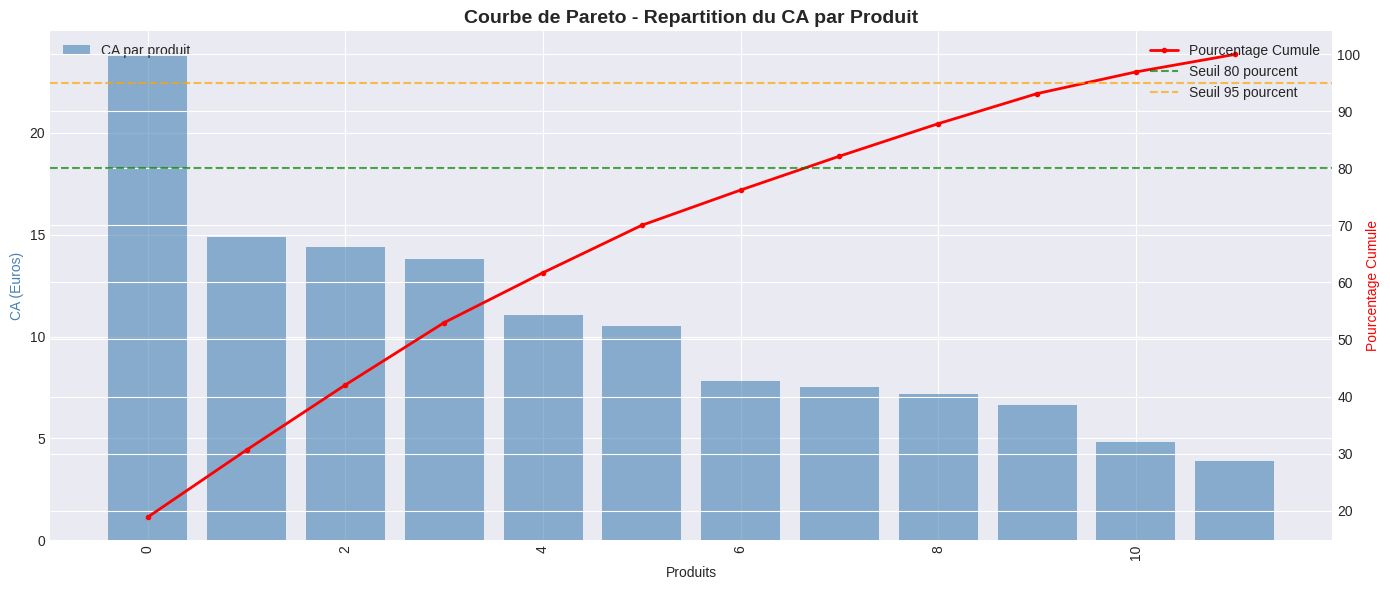

In [30]:
if 'df' in locals() and 'nom_produit' in df.columns:
    print("MATRICE ABC - LOI DE PARETO 80/20")
    print("-" * 50)
    
    produits_ca = df.groupby('nom_produit')['montant_ttc'].sum().sort_values(ascending=False)
    ca_cumule = produits_ca.cumsum()
    total_ca = produits_ca.sum()
    pct_cumule = (ca_cumule / total_ca * 100)
    
    abc_df = pd.DataFrame({
        'Produit': produits_ca.index,
        'CA': produits_ca.values,
        'CA_Cumule': ca_cumule.values,
        'Pourcentage_Cumule': pct_cumule.values
    })
    
    def categorie_abc(pct):
        if pct <= 80:
            return 'A - 80 pourcent du CA'
        elif pct <= 95:
            return 'B - 15 pourcent du CA'
        else:
            return 'C - 5 pourcent du CA'
    
    abc_df['Categorie'] = abc_df['Pourcentage_Cumule'].apply(categorie_abc)
    
    print("CLASSIFICATION DES PRODUITS")
    display(abc_df.head(20))
    
    categorie_stats = abc_df.groupby('Categorie').agg({
        'Produit': 'count',
        'CA': ['sum', 'mean']
    }).round(2)
    
    categorie_stats.columns = ['Nb_Produits', 'CA_Total', 'CA_Moyen']
    categorie_stats['Pourcentage_CA'] = (categorie_stats['CA_Total'] / total_ca * 100).round(2)
    
    print("\nSTATISTIQUES PAR CATEGORIE ABC")
    display(categorie_stats)
    
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    ax1.bar(range(len(produits_ca)), produits_ca.values, alpha=0.6, color='steelblue', label='CA par produit')
    ax1.set_xlabel('Produits')
    ax1.set_ylabel('CA (Euros)', color='steelblue')
    ax1.tick_params(axis='x', labelrotation=90)
    
    ax2 = ax1.twinx()
    ax2.plot(range(len(pct_cumule)), pct_cumule.values, 'r-', linewidth=2, marker='o', markersize=3, label='Pourcentage Cumule')
    ax2.set_ylabel('Pourcentage Cumule', color='red')
    ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='Seuil 80 pourcent')
    ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='Seuil 95 pourcent')
    
    plt.title('Courbe de Pareto - Repartition du CA par Produit', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

ANALYSE DES EMPLOYES
--------------------------------------------------
Utilisation de la colonne magasin: nom_magasin_x

TOP 10 EMPLOYES PAR CA REALISE


,,,CA_Realise,Nb_Ventes,Quantite,Panier_Moyen
nom_employe,poste,nom_magasin_x,,,,
Luc Moreau,Caissier,Supermarche A - Sud,24.20,3,9,8.07
Jean Dupont,Caissier,Supermarche A - Centre,23.40,4,9,5.85
Paul Martin,Caissier,Supermarche A - Nord,22.25,3,17,7.42
Claire Simon,Responsable rayon,Supermarche A - Sud,18.90,2,8,9.45
Marie Lefebvre,Responsable rayon,Supermarche A - Centre,12.50,3,9,4.17
Sophie Bernard,Chef de caisse,Supermarche A - Nord,9.75,2,5,4.88
Marc Laurent,Caissier,Supermarche A - Est,7.77,2,3,3.88
Julie Petit,Chef de caisse,Supermarche A - Est,7.50,1,3,7.50


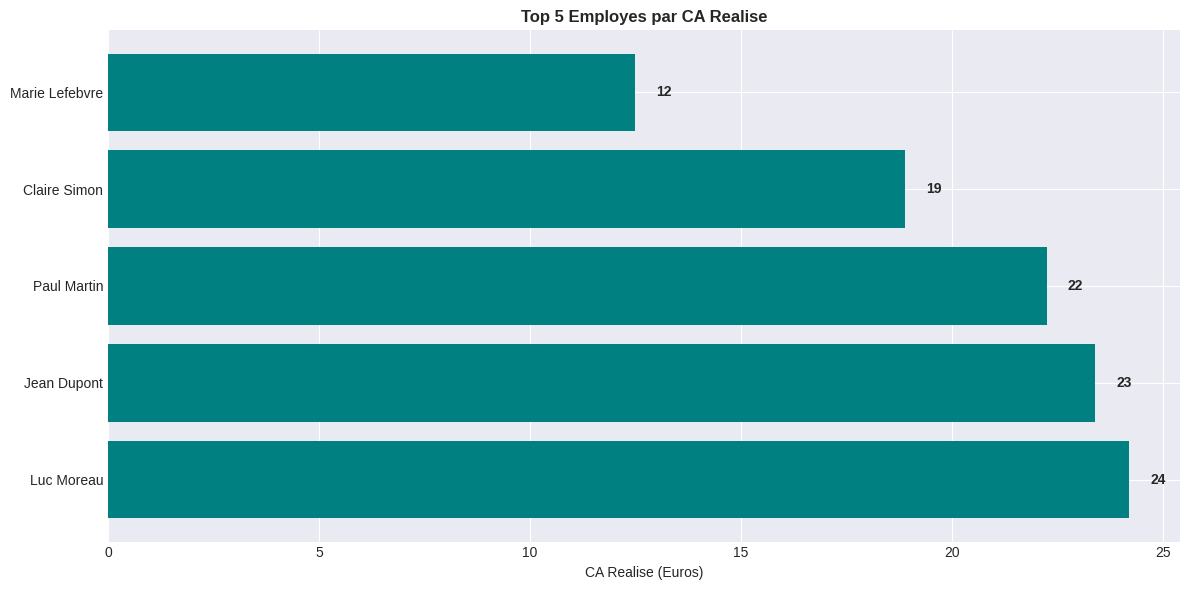

In [34]:
if 'df' in locals() and 'nom_employe' in df.columns:
    print("ANALYSE DES EMPLOYES")
    print("-" * 50)
    
    # Identifier la bonne colonne pour le magasin
    if 'nom_magasin_x' in df.columns:
        colonne_magasin = 'nom_magasin_x'
    elif 'nom_magasin_y' in df.columns:
        colonne_magasin = 'nom_magasin_y'
    else:
        colonne_magasin = None
        print("Attention: Colonne magasin non trouvee")
    
    print(f"Utilisation de la colonne magasin: {colonne_magasin}")
    
    # Grouper par employe, poste et magasin
    if colonne_magasin:
        perf_employes = df.groupby(['nom_employe', 'poste', colonne_magasin]).agg({
            'montant_ttc': 'sum',
            'id_vente': 'count',
            'quantite': 'sum'
        }).rename(columns={'montant_ttc': 'CA_Realise', 'id_vente': 'Nb_Ventes', 'quantite': 'Quantite'}).round(2)
        
        perf_employes['Panier_Moyen'] = (perf_employes['CA_Realise'] / perf_employes['Nb_Ventes']).round(2)
        perf_employes = perf_employes.sort_values('CA_Realise', ascending=False)
        
        print("\nTOP 10 EMPLOYES PAR CA REALISE")
        display(perf_employes.head(10))
        
        # Graphique
        fig, ax = plt.subplots(figsize=(12, 6))
        top5_employes = perf_employes.head(5)
        
        # Extraire les noms des employes
        noms_employes = [idx[0] for idx in top5_employes.index]
        
        ax.barh(range(len(top5_employes)), top5_employes['CA_Realise'], color='teal')
        ax.set_yticks(range(len(top5_employes)))
        ax.set_yticklabels(noms_employes)
        ax.set_title('Top 5 Employes par CA Realise', fontsize=12, fontweight='bold')
        ax.set_xlabel('CA Realise (Euros)')
        
        # Ajouter les valeurs sur les barres
        for i, v in enumerate(top5_employes['CA_Realise']):
            ax.text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
    else:
        # Version simplifiee sans le magasin
        print("\nVersion simplifiee (sans regroupement par magasin)")
        
        perf_employes = df.groupby(['nom_employe', 'poste']).agg({
            'montant_ttc': 'sum',
            'id_vente': 'count',
            'quantite': 'sum'
        }).rename(columns={'montant_ttc': 'CA_Realise', 'id_vente': 'Nb_Ventes', 'quantite': 'Quantite'}).round(2)
        
        perf_employes['Panier_Moyen'] = (perf_employes['CA_Realise'] / perf_employes['Nb_Ventes']).round(2)
        perf_employes = perf_employes.sort_values('CA_Realise', ascending=False)
        
        print("\nTOP 10 EMPLOYES PAR CA REALISE")
        display(perf_employes.head(10))
        
        # Graphique
        fig, ax = plt.subplots(figsize=(12, 6))
        top5_employes = perf_employes.head(5)
        
        ax.barh(range(len(top5_employes)), top5_employes['CA_Realise'], color='teal')
        ax.set_yticks(range(len(top5_employes)))
        ax.set_yticklabels(top5_employes.index.get_level_values(0))
        ax.set_title('Top 5 Employes par CA Realise', fontsize=12, fontweight='bold')
        ax.set_xlabel('CA Realise (Euros)')
        
        # Ajouter les valeurs sur les barres
        for i, v in enumerate(top5_employes['CA_Realise']):
            ax.text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

ANALYSE DES CORRELATIONS ET INSIGHTS PROFESSIONNELS

1. MATRICE DE CORRELATION
----------------------------------------
Matrice de correlation entre les variables numeriques:


,quantite,montant_ht,montant_ttc,prix_unitaire,taux_remise
quantite,1.000,0.424,0.464,-0.551,-0.312
montant_ht,0.424,1.000,0.989,0.329,0.021
montant_ttc,0.464,0.989,1.000,0.272,-0.082
prix_unitaire,-0.551,0.329,0.272,1.000,0.318
taux_remise,-0.312,0.021,-0.082,0.318,1.000


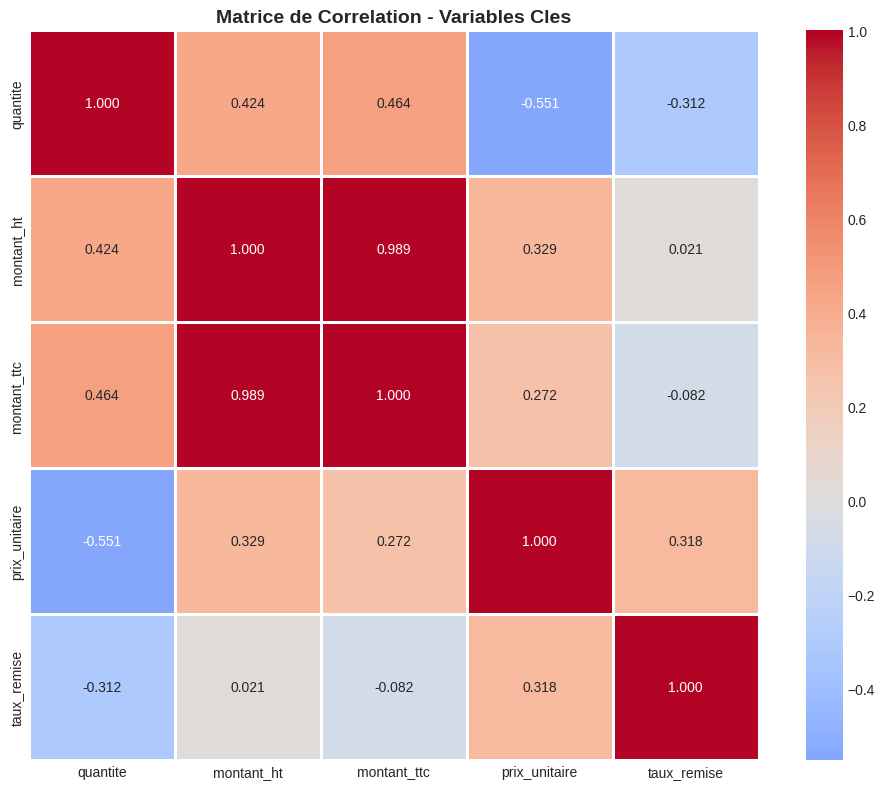


2. ANALYSE DES PRODUITS SOUVENT ACHETES ENSEMBLE (CROSS-SELLING)
------------------------------------------------------------
Aucune combinaison de produits trouvee

3. MEILLEURES COMBINAISONS MAGASIN-PRODUIT
------------------------------------------------------------
TOP 10 COMBINAISONS MAGASIN-PRODUIT PAR CA:
--------------------------------------------------
  • Supermarche A - Sud - Essuie-tout x4: 13.80 Euros
  • Supermarche A - Sud - Coca-Cola 2L: 12.60 Euros
  • Supermarche A - Nord - Coca-Cola 2L: 11.20 Euros
  • Supermarche A - Nord - Pates 500g: 11.05 Euros
  • Supermarche A - Sud - Jus d orange 1L: 10.50 Euros
  • Supermarche A - Centre - Lessive liquide 3L: 8.68 Euros
  • Supermarche A - Est - Dentifrice 75ml: 7.50 Euros
  • Supermarche A - Nord - Eau minerale 6x1.5L: 7.35 Euros
  • Supermarche A - Centre - Eau minerale 6x1.5L: 7.06 Euros
  • Supermarche A - Centre - Lait entier 1L: 6.66 Euros


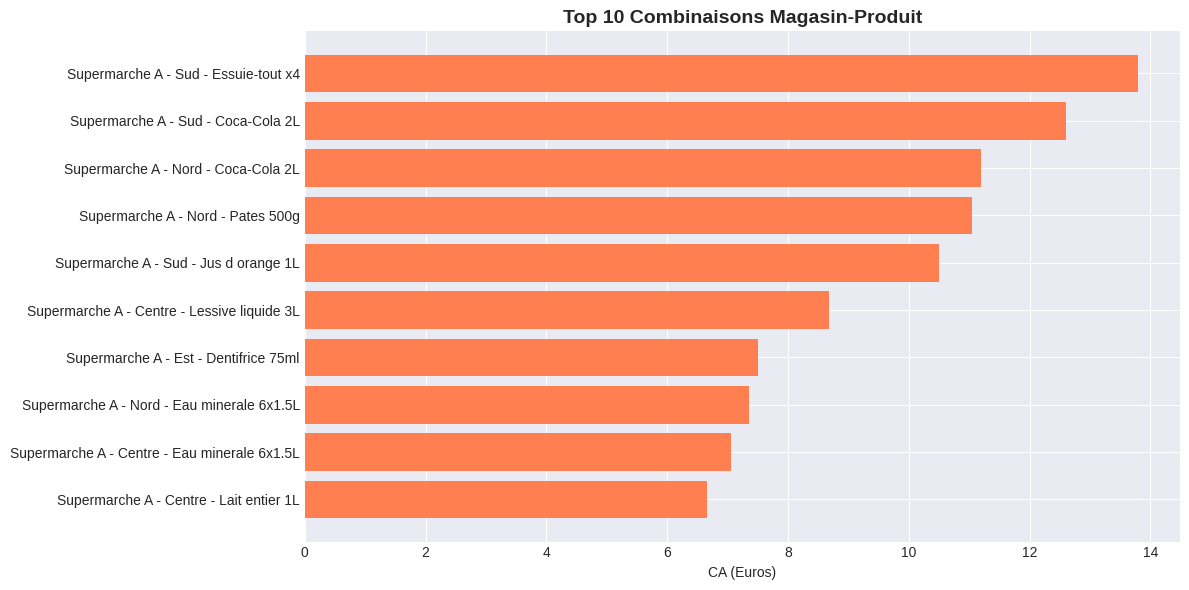


4. ANALYSE DU PANIER MOYEN PAR CATEGORIE
------------------------------------------------------------
Panier moyen par categorie de produits:


,Panier_Moyen,CA_Total,Nb_Ventes,Quantite_Moyenne
nom_categorie,,,,
Entretien Maison,9.56,28.68,3,3.00
Boissons,8.12,48.71,6,3.17
Hygiene Beaute,5.10,15.30,3,1.67
Epicerie Seche,4.97,14.92,3,5.00
Alimentation,3.73,18.66,5,3.00


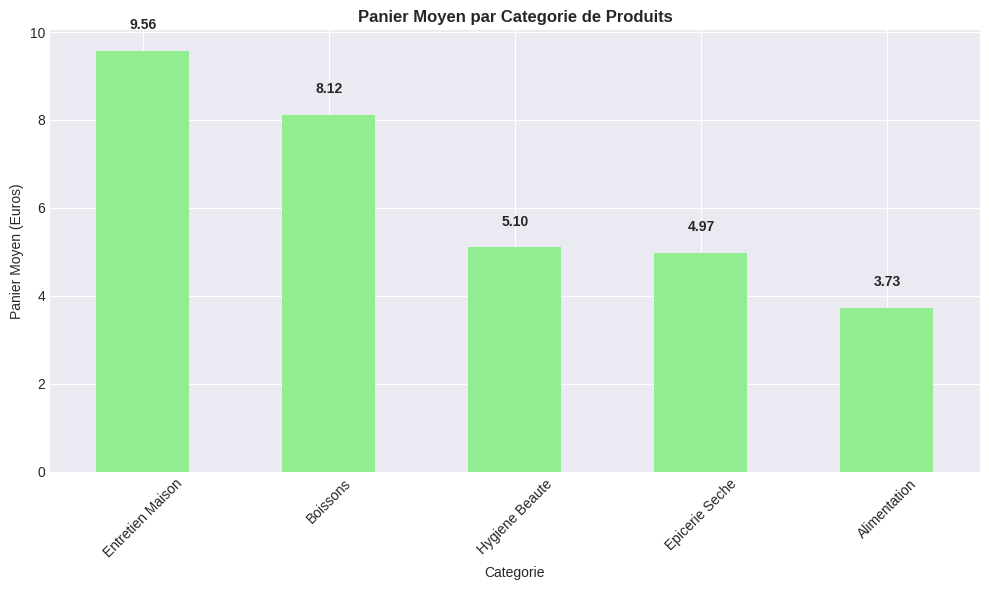


5. INSIGHTS STRATEGIQUES ET RECOMMANDATIONS

IMPACT PROMOTIONS:
  • Les promotions generent -13.4% de CA supplementaire

PERFORMANCE TEMPORELLE:
  • Meilleur jour de vente: Tuesday

PERFORMANCE MAGASINS:
  • Meilleur magasin: Supermarche A - Sud

PERFORMANCE CLIENTS:
  • Meilleur client: Awa Diallo (23.72 Euros)


In [47]:
if 'df' in locals():
    print("ANALYSE DES CORRELATIONS ET INSIGHTS PROFESSIONNELS")
    print("=" * 60)
    
    # 1. MATRICE DE CORRELATION COMPLETE
    print("\n1. MATRICE DE CORRELATION")
    print("-" * 40)
    
    # Selectionner les colonnes numeriques
    colonnes_numeriques = ['quantite', 'montant_ht', 'montant_ttc', 'prix_unitaire', 'taux_remise']
    colonnes_disponibles = [col for col in colonnes_numeriques if col in df.columns]
    
    if len(colonnes_disponibles) >= 2:
        matrice_correlation = df[colonnes_disponibles].corr()
        
        print("Matrice de correlation entre les variables numeriques:")
        display(matrice_correlation.round(3))
        
        # Heatmap de correlation
        plt.figure(figsize=(10, 8))
        sns.heatmap(matrice_correlation, annot=True, cmap='coolwarm', center=0, 
                    fmt='.3f', square=True, linewidths=1)
        plt.title('Matrice de Correlation - Variables Cles', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # 2. ANALYSE PRODUITS SOUVENT ACHETES ENSEMBLE (CROSS-SELLING)
    print("\n2. ANALYSE DES PRODUITS SOUVENT ACHETES ENSEMBLE (CROSS-SELLING)")
    print("-" * 60)
    
    from itertools import combinations
    from collections import Counter
    
    # Analyser les paniers
    paniers = df.groupby('id_vente')['nom_produit'].apply(list)
    combinations_list = []
    
    for panier in paniers:
        if len(panier) > 1:
            # Prendre toutes les combinaisons possibles dans le panier
            combinations_list.extend(combinations(sorted(panier), 2))
    
    if combinations_list:
        top_combinations = Counter(combinations_list).most_common(10)
        
        print("TOP 10 DES ASSOCIATIONS DE PRODUITS LES PLUS FREQUENTES:")
        print("-" * 50)
        
        for i, (combo, count) in enumerate(top_combinations, 1):
            print(f"{i:2d}. {combo[0]} + {combo[1]}: {count} fois")
        
        # Creer un DataFrame pour visualisation
        df_combos = pd.DataFrame(top_combinations, columns=['Association', 'Frequence'])
        df_combos['Association'] = df_combos['Association'].apply(lambda x: f"{x[0]} + {x[1]}")
        
        # Graphique
        plt.figure(figsize=(12, 6))
        plt.barh(range(len(df_combos.head(8))), df_combos.head(8)['Frequence'], color='steelblue')
        plt.yticks(range(len(df_combos.head(8))), df_combos.head(8)['Association'])
        plt.xlabel('Nombre de fois achetes ensemble')
        plt.title('Top 8 des Associations de Produits (Cross-Selling)', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
        # Recommandations cross-selling
        print("\nRECOMMANDATIONS CROSS-SELLING:")
        print("-" * 40)
        for i, (combo, count) in enumerate(top_combinations[:3], 1):
            print(f"  • Proposer {combo[0]} avec {combo[1]} - Vente conjointe: {count} fois")
    
    else:
        print("Aucune combinaison de produits trouvee")
    
    # 3. MEILLEURES COMBINAISONS MAGASIN-PRODUIT
    print("\n3. MEILLEURES COMBINAISONS MAGASIN-PRODUIT")
    print("-" * 60)
    
    # Identifier la bonne colonne magasin
    colonne_magasin = None
    if 'nom_magasin_x' in df.columns:
        colonne_magasin = 'nom_magasin_x'
    elif 'nom_magasin_y' in df.columns:
        colonne_magasin = 'nom_magasin_y'
    elif 'nom_magasin' in df.columns:
        colonne_magasin = 'nom_magasin'
    
    if colonne_magasin and 'nom_produit' in df.columns:
        top_combos = df.groupby([colonne_magasin, 'nom_produit'])['montant_ttc'].sum().sort_values(ascending=False).head(10)
        
        print("TOP 10 COMBINAISONS MAGASIN-PRODUIT PAR CA:")
        print("-" * 50)
        
        combo_data = []
        for (magasin, produit), ca in top_combos.items():
            combo_data.append({'Magasin': magasin, 'Produit': produit, 'CA': ca})
            print(f"  • {magasin} - {produit}: {ca:.2f} Euros")
        
        df_combos_magasin = pd.DataFrame(combo_data)
        
        # Graphique
        plt.figure(figsize=(12, 6))
        bars = plt.barh(range(len(df_combos_magasin)), df_combos_magasin['CA'], color='coral')
        plt.yticks(range(len(df_combos_magasin)), 
                   [f"{row['Magasin']} - {row['Produit'][:20]}" for _, row in df_combos_magasin.iterrows()])
        plt.xlabel('CA (Euros)')
        plt.title('Top 10 Combinaisons Magasin-Produit', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    
    # 4. ANALYSE DU PANIER MOYEN PAR SEGMENT
    print("\n4. ANALYSE DU PANIER MOYEN PAR CATEGORIE")
    print("-" * 60)
    
    if 'nom_categorie' in df.columns:
        panier_par_categorie = df.groupby('nom_categorie').agg({
            'montant_ttc': ['mean', 'sum', 'count'],
            'quantite': 'mean'
        }).round(2)
        
        panier_par_categorie.columns = ['Panier_Moyen', 'CA_Total', 'Nb_Ventes', 'Quantite_Moyenne']
        panier_par_categorie = panier_par_categorie.sort_values('Panier_Moyen', ascending=False)
        
        print("Panier moyen par categorie de produits:")
        display(panier_par_categorie)
        
        # Graphique
        fig, ax = plt.subplots(figsize=(10, 6))
        panier_par_categorie['Panier_Moyen'].plot(kind='bar', ax=ax, color='lightgreen')
        ax.set_title('Panier Moyen par Categorie de Produits', fontsize=12, fontweight='bold')
        ax.set_xlabel('Categorie')
        ax.set_ylabel('Panier Moyen (Euros)')
        ax.tick_params(axis='x', rotation=45)
        
        # Ajouter les valeurs
        for i, v in enumerate(panier_par_categorie['Panier_Moyen']):
            ax.text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    # 5. INSIGHTS STRATEGIQUES
    print("\n5. INSIGHTS STRATEGIQUES ET RECOMMANDATIONS")
    print("=" * 60)
    
    # Calculer des metriques additionnelles
    if 'type_vente' in df.columns:
        ca_avec_promo = df[df['type_vente'] == 'Avec Promotion']['montant_ttc'].sum()
        ca_sans_promo = df[df['type_vente'] == 'Sans Promotion']['montant_ttc'].sum()
        lift_promo = ((ca_avec_promo / ca_sans_promo) - 1) * 100 if ca_sans_promo > 0 else 0
        
        print(f"\nIMPACT PROMOTIONS:")
        print(f"  • Les promotions generent {lift_promo:.1f}% de CA supplementaire")
    
    if 'jour_semaine' in df.columns:
        meilleur_jour = df.groupby('jour_semaine')['montant_ttc'].sum().idxmax()
        print(f"\nPERFORMANCE TEMPORELLE:")
        print(f"  • Meilleur jour de vente: {meilleur_jour}")
    
    if colonne_magasin:
        meilleur_magasin = df.groupby(colonne_magasin)['montant_ttc'].sum().idxmax()
        print(f"\nPERFORMANCE MAGASINS:")
        print(f"  • Meilleur magasin: {meilleur_magasin}")
    
    if 'nom_client' in df.columns:
        top_client = df.groupby('nom_client')['montant_ttc'].sum().idxmax()
        top_client_ca = df.groupby('nom_client')['montant_ttc'].sum().max()
        print(f"\nPERFORMANCE CLIENTS:")
        print(f"  • Meilleur client: {top_client} ({top_client_ca:.2f} Euros)")
    
   
   

ANALYSES AVANCEES AVEC 3 MODELES DE PREDICTION

1. TABLEAU DE BORD TEMPS REEL
----------------------------------------


,Indicateur,Valeur
0,Ventes dernieres 24h (Euros),15.48
1,Ventes 7 derniers jours (Euros),31.98
2,Ventes 30 derniers jours (Euros),31.98
3,Evolution 7j vs semaine precedente (%),0.0%
4,Panier moyen 24h (Euros),7.74
5,Transactions 24h,2


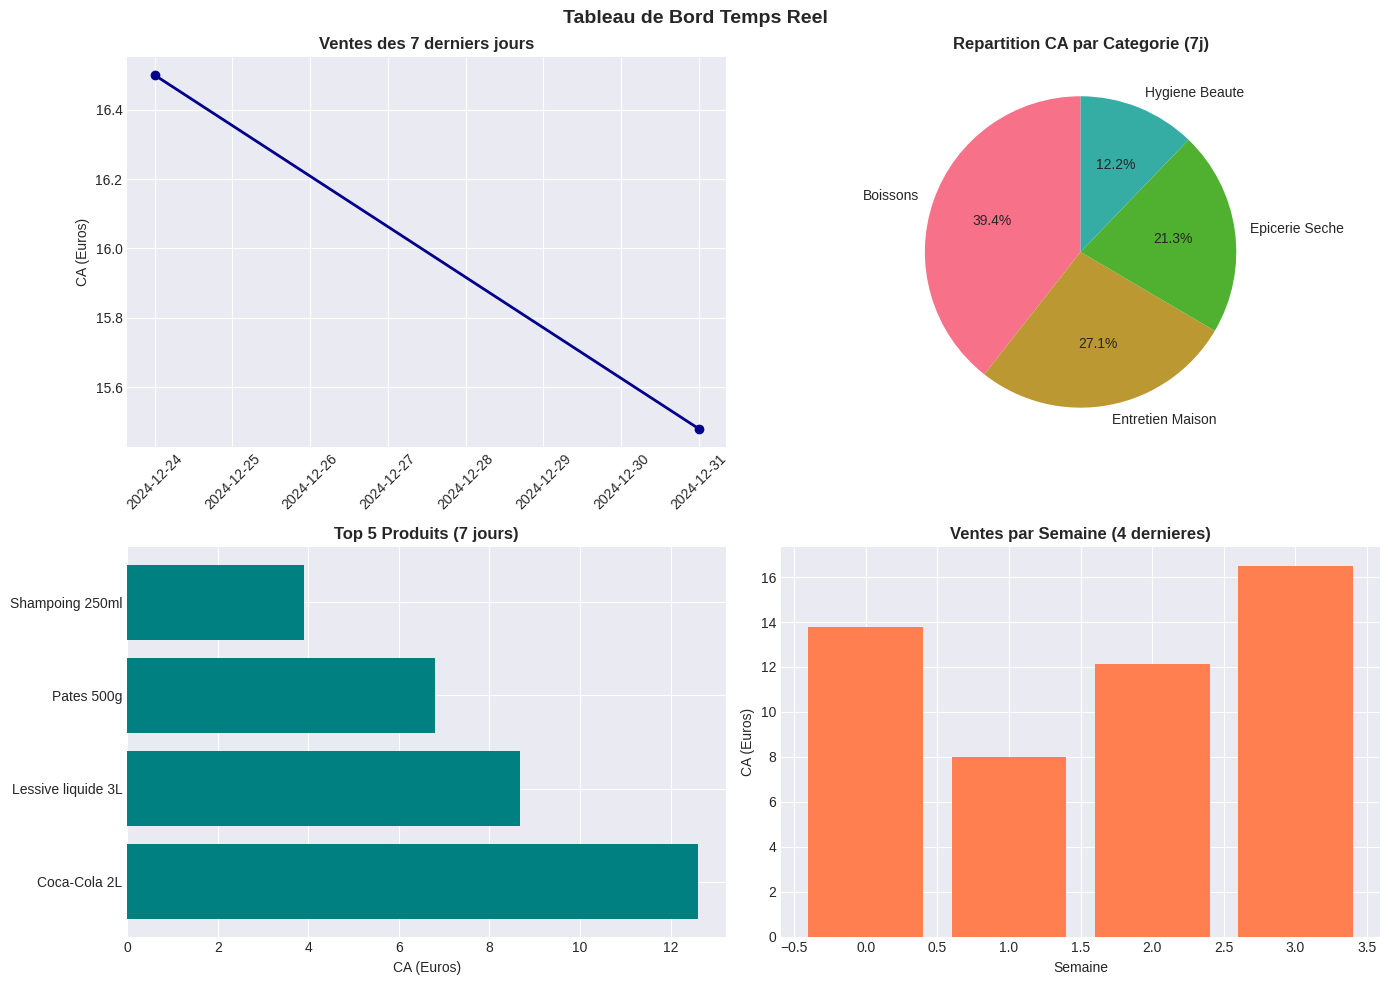


2. PREPARATION DES DONNEES POUR LA PREDICTION
----------------------------------------
Nombre de jours disponibles pour l'entrainement: 8


,date_complete,montant_ttc,jour_num,jour_semaine,mois,semaine,lag_1,lag_2,lag_3,lag_7,moyenne_mobile_3,moyenne_mobile_7
7,2024-06-30,11.20,7,6,6,26,4.80,6.30,6.20,9.92,7.433333,5.578571
8,2024-07-14,3.87,8,6,7,28,11.20,4.80,6.30,3.90,6.623333,5.574286
9,2024-08-01,7.50,9,3,8,31,3.87,11.20,4.80,4.25,7.523333,6.038571
10,2024-09-09,13.80,10,0,9,37,7.50,3.87,11.20,2.40,8.390000,7.667143
11,2024-10-25,8.00,11,4,10,43,13.80,7.50,3.87,6.20,9.766667,7.924286
12,2024-11-11,12.15,12,0,11,46,8.00,13.80,7.50,6.30,11.316667,8.760000
13,2024-12-24,16.50,13,1,12,52,12.15,8.00,13.80,4.80,12.216667,10.431429
14,2024-12-31,15.48,14,1,12,1,16.50,12.15,8.00,11.20,14.710000,11.042857



3. COMPARAISON DE 3 MODELES DE PREDICTION
Donnees d'entrainement: 6 jours
Donnees de test: 2 jours

----------------------------------------
MODELE 1: REGRESSION LINEAIRE
----------------------------------------
Erreur Absolue Moyenne (MAE): 11.86 Euros
Racine Erreur Quadratique (RMSE): 16.35 Euros
Coefficient R2: -1026.658
Interpretation: Le modele explique -102665.8% de la variance

----------------------------------------
MODELE 2: ARBRE DE DECISION
----------------------------------------
Erreur Absolue Moyenne (MAE): 3.84 Euros
Racine Erreur Quadratique (RMSE): 3.87 Euros
Coefficient R2: -56.692
Interpretation: Le modele explique -5669.2% de la variance

Importance des variables (Arbre de Decision):


,Feature,Importance
6,lag_3,0.571761
7,lag_7,0.405825
2,mois,0.022413
0,jour_num,0.000000
1,jour_semaine,0.000000
3,semaine,0.000000
5,lag_2,0.000000
4,lag_1,0.000000
8,moyenne_mobile_3,0.000000
9,moyenne_mobile_7,0.000000



----------------------------------------
MODELE 3: FORET ALEATOIRE (RANDOM FOREST)
----------------------------------------
Erreur Absolue Moyenne (MAE): 6.09 Euros
Racine Erreur Quadratique (RMSE): 6.14 Euros
Coefficient R2: -143.948
Interpretation: Le modele explique -14394.8% de la variance

Importance des variables (Random Forest):


...


4. COMPARAISON DES 3 MODELES
Tableau comparatif des 3 modeles:


,Modele,MAE (Euros),RMSE (Euros),R2,Precision (%)
0,Regression Lineaire,11.86,16.35,-1026.66,-102665.82
1,Arbre de Decision,3.84,3.87,-56.69,-5669.20
2,Foret Aleatoire,6.09,6.14,-143.95,-14394.76



MEILLEUR MODELE: Arbre de Decision (R2 = -56.690)

5. PREDICTIONS DES 7 PROCHAINS JOURS
Predictions avec le meilleur modele (Arbre de Decision):


,Date,Jour,CA_Predit (Euros)
0,2025-01-01,Wednesday,12.15
1,2025-01-02,Thursday,12.15
2,2025-01-03,Friday,12.15
3,2025-01-04,Saturday,12.15
4,2025-01-05,Sunday,12.15
5,2025-01-06,Monday,12.15
6,2025-01-07,Tuesday,12.15



CA total prevu pour les 7 prochains jours: 85.05 Euros
CA moyen journalier prevu: 12.15 Euros

6. VISUALISATION COMPARATIVE
----------------------------------------


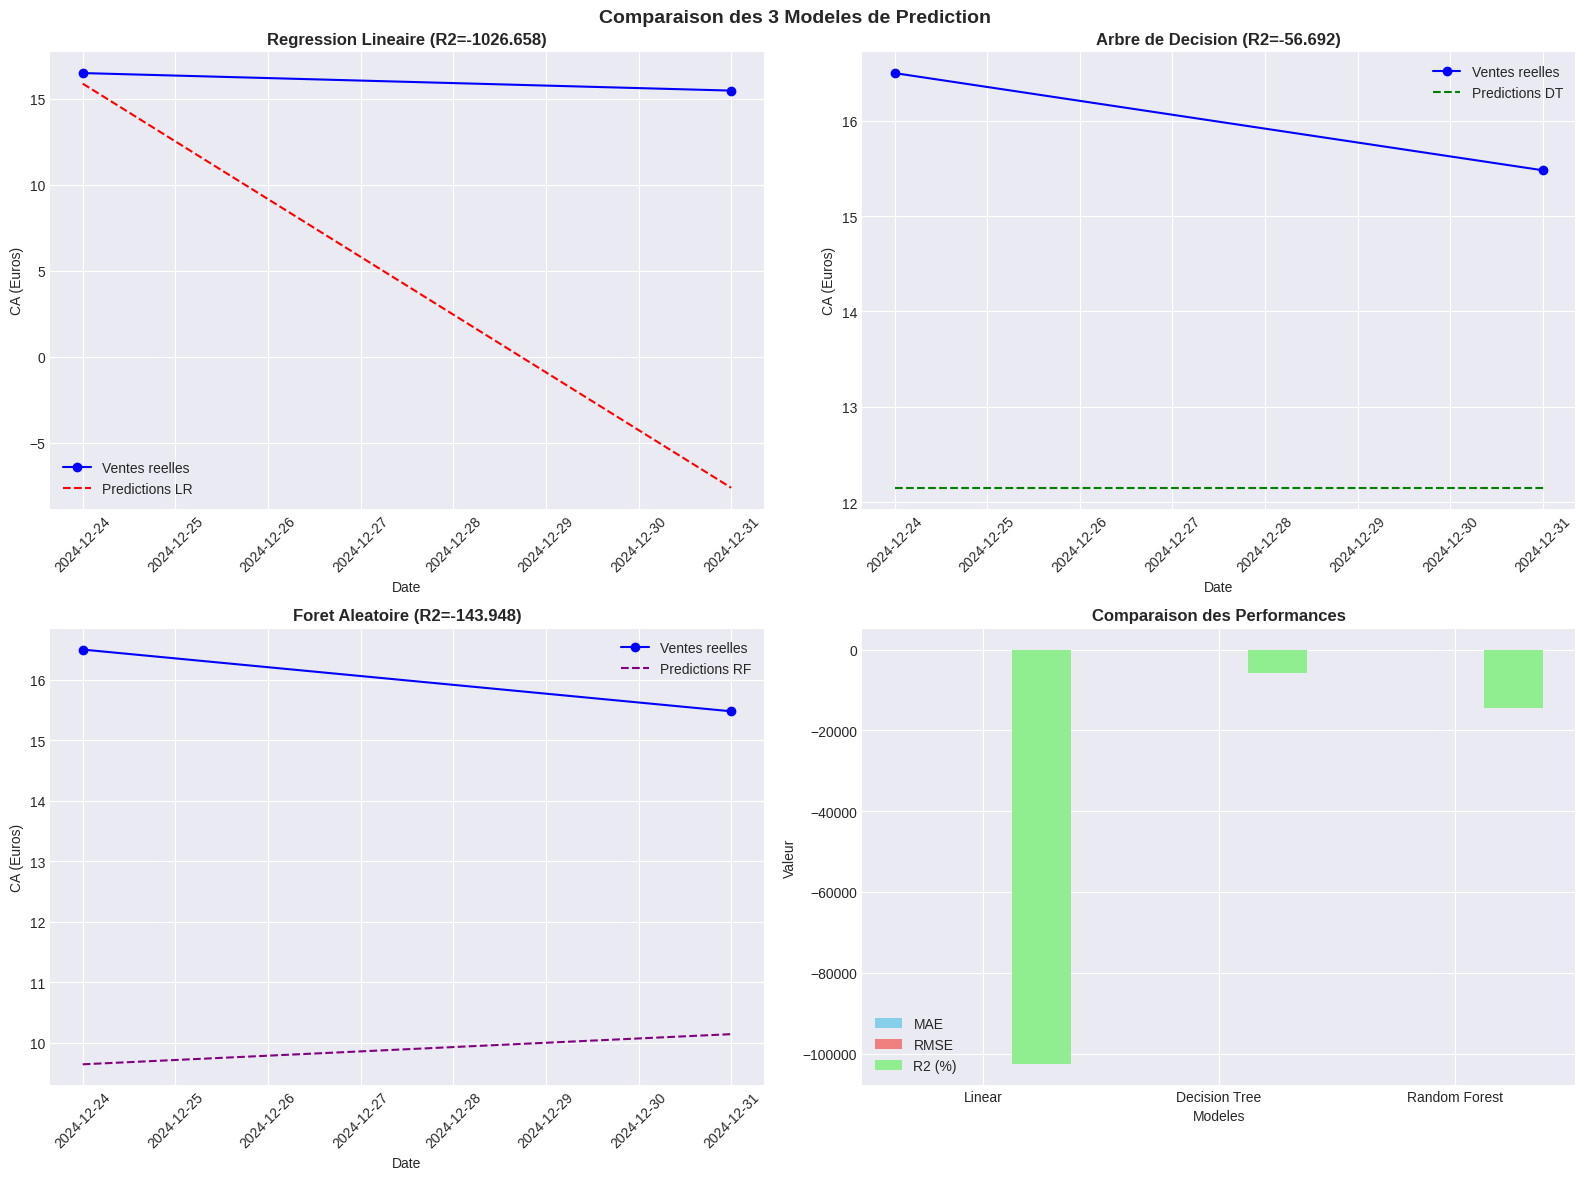


7. PREDICTIONS FUTURES AVEC LE MEILLEUR MODELE
----------------------------------------


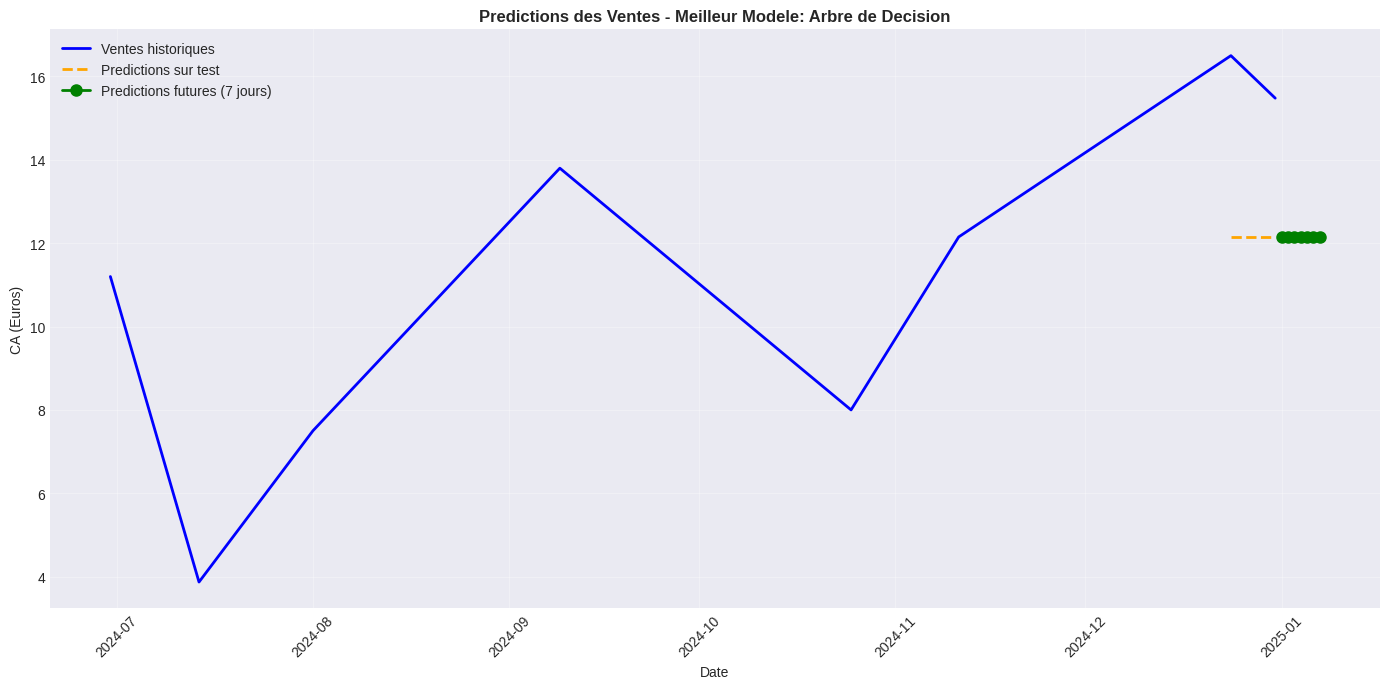


RESUME FINAL DES 3 MODELES


,Modele,R2 Score,MAE (Euros),Interpretation
0,Regression Lineaire,-1026.658,11.864,Explique -102665.8% des ventes
1,Arbre de Decision,-56.692,3.840,Explique -5669.2% des ventes
2,Foret Aleatoire,-143.948,6.093,Explique -14394.8% des ventes



CONCLUSION: Le meilleur modele est Arbre de Decision avec R2 = -56.690


In [46]:
if 'df' in locals():
    print("ANALYSES AVANCEES AVEC 3 MODELES DE PREDICTION")
    print("=" * 60)
    
    # 1. TABLEAU DE BORD TEMPS REEL
    print("\n1. TABLEAU DE BORD TEMPS REEL")
    print("-" * 40)
    
    from datetime import datetime, timedelta
    
    dernieres_dates = df['date_complete'].max()
    date_debut = dernieres_dates - timedelta(days=30)
    
    ventes_recentes = df[df['date_complete'] >= date_debut]
    
    dashboard = {
        'Ventes_24h': df[df['date_complete'] == dernieres_dates]['montant_ttc'].sum(),
        'Ventes_7j': df[df['date_complete'] >= dernieres_dates - timedelta(days=7)]['montant_ttc'].sum(),
        'Ventes_30j': ventes_recentes['montant_ttc'].sum(),
        'Panier_moyen_24h': df[df['date_complete'] == dernieres_dates]['montant_ttc'].mean(),
        'Transactions_24h': df[df['date_complete'] == dernieres_dates]['id_vente'].nunique()
    }
    
    # Calcul evolution
    ventes_7j_prec = df[(df['date_complete'] >= dernieres_dates - timedelta(days=14)) & 
                         (df['date_complete'] < dernieres_dates - timedelta(days=7))]['montant_ttc'].sum()
    
    if ventes_7j_prec > 0:
        dashboard['Evolution_7j'] = ((dashboard['Ventes_7j'] - ventes_7j_prec) / ventes_7j_prec * 100)
    else:
        dashboard['Evolution_7j'] = 0
    
    # Affichage dashboard
    dashboard_df = pd.DataFrame({
        'Indicateur': [
            'Ventes dernieres 24h (Euros)',
            'Ventes 7 derniers jours (Euros)',
            'Ventes 30 derniers jours (Euros)',
            'Evolution 7j vs semaine precedente (%)',
            'Panier moyen 24h (Euros)',
            'Transactions 24h'
        ],
        'Valeur': [
            f"{dashboard['Ventes_24h']:.2f}",
            f"{dashboard['Ventes_7j']:.2f}",
            f"{dashboard['Ventes_30j']:.2f}",
            f"{dashboard['Evolution_7j']:.1f}%",
            f"{dashboard['Panier_moyen_24h']:.2f}",
            f"{dashboard['Transactions_24h']}"
        ]
    })
    
    display(dashboard_df)
    
    # Dashboard graphique
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Tableau de Bord Temps Reel', fontsize=14, fontweight='bold')
    
    # Ventes 7 jours
    ventes_7j = df[df['date_complete'] >= dernieres_dates - timedelta(days=7)].groupby('date_complete')['montant_ttc'].sum()
    axes[0,0].plot(ventes_7j.index, ventes_7j.values, marker='o', linewidth=2, color='darkblue')
    axes[0,0].set_title('Ventes des 7 derniers jours', fontweight='bold')
    axes[0,0].set_ylabel('CA (Euros)')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Repartition CA par categorie (7 jours)
    ca_categorie_7j = df[df['date_complete'] >= dernieres_dates - timedelta(days=7)].groupby('nom_categorie')['montant_ttc'].sum()
    if len(ca_categorie_7j) > 0:
        axes[0,1].pie(ca_categorie_7j.values, labels=ca_categorie_7j.index, autopct='%1.1f%%', startangle=90)
        axes[0,1].set_title('Repartition CA par Categorie (7j)', fontweight='bold')
    
    # Top produits 7 jours
    top_produits_7j = df[df['date_complete'] >= dernieres_dates - timedelta(days=7)].groupby('nom_produit')['montant_ttc'].sum().head(5)
    axes[1,0].barh(range(len(top_produits_7j)), top_produits_7j.values, color='teal')
    axes[1,0].set_yticks(range(len(top_produits_7j)))
    axes[1,0].set_yticklabels(top_produits_7j.index)
    axes[1,0].set_title('Top 5 Produits (7 jours)', fontweight='bold')
    axes[1,0].set_xlabel('CA (Euros)')
    
    # Evolution hebdomadaire
    ventes_semaine = df.groupby(df['date_complete'].dt.isocalendar().week)['montant_ttc'].sum().tail(4)
    axes[1,1].bar(range(len(ventes_semaine)), ventes_semaine.values, color='coral')
    axes[1,1].set_title('Ventes par Semaine (4 dernieres)', fontweight='bold')
    axes[1,1].set_xlabel('Semaine')
    axes[1,1].set_ylabel('CA (Euros)')
    
    plt.tight_layout()
    plt.show()
    
    # 2. PREPARATION DES DONNEES POUR LES 3 MODELES
    print("\n2. PREPARATION DES DONNEES POUR LA PREDICTION")
    print("-" * 40)
    
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import warnings
    warnings.filterwarnings('ignore')
    
    # Preparation des donnees
    ventes_par_jour = df.groupby('date_complete')['montant_ttc'].sum().reset_index()
    ventes_par_jour['jour_num'] = range(len(ventes_par_jour))
    ventes_par_jour['jour_semaine'] = ventes_par_jour['date_complete'].dt.dayofweek
    ventes_par_jour['mois'] = ventes_par_jour['date_complete'].dt.month
    ventes_par_jour['semaine'] = ventes_par_jour['date_complete'].dt.isocalendar().week
    
    # Creer des features de lag
    for lag in [1, 2, 3, 7]:
        ventes_par_jour[f'lag_{lag}'] = ventes_par_jour['montant_ttc'].shift(lag)
    
    ventes_par_jour['moyenne_mobile_3'] = ventes_par_jour['montant_ttc'].rolling(window=3).mean()
    ventes_par_jour['moyenne_mobile_7'] = ventes_par_jour['montant_ttc'].rolling(window=7).mean()
    
    # Supprimer les valeurs manquantes
    ventes_par_jour = ventes_par_jour.dropna()
    
    print(f"Nombre de jours disponibles pour l'entrainement: {len(ventes_par_jour)}")
    display(ventes_par_jour.head(10))
    
    # 3. TROIS MODELES DE PREDICTION
    print("\n3. COMPARAISON DE 3 MODELES DE PREDICTION")
    print("=" * 60)
    
    # Features pour la prediction
    features = ['jour_num', 'jour_semaine', 'mois', 'semaine', 
                'lag_1', 'lag_2', 'lag_3', 'lag_7', 
                'moyenne_mobile_3', 'moyenne_mobile_7']
    features = [f for f in features if f in ventes_par_jour.columns]
    
    X = ventes_par_jour[features]
    y = ventes_par_jour['montant_ttc']
    
    # Separer train (80%) et test (20%)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"Donnees d'entrainement: {len(X_train)} jours")
    print(f"Donnees de test: {len(X_test)} jours")
    
    # Modele 1: Regression Lineaire
    print("\n" + "-" * 40)
    print("MODELE 1: REGRESSION LINEAIRE")
    print("-" * 40)
    
    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    predictions_lr = model_lr.predict(X_test)
    
    mae_lr = mean_absolute_error(y_test, predictions_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, predictions_lr))
    r2_lr = r2_score(y_test, predictions_lr)
    
    print(f"Erreur Absolue Moyenne (MAE): {mae_lr:.2f} Euros")
    print(f"Racine Erreur Quadratique (RMSE): {rmse_lr:.2f} Euros")
    print(f"Coefficient R2: {r2_lr:.3f}")
    print(f"Interpretation: Le modele explique {r2_lr*100:.1f}% de la variance")
    
    # Modele 2: Arbre de Decision
    print("\n" + "-" * 40)
    print("MODELE 2: ARBRE DE DECISION")
    print("-" * 40)
    
    model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
    model_dt.fit(X_train, y_train)
    predictions_dt = model_dt.predict(X_test)
    
    mae_dt = mean_absolute_error(y_test, predictions_dt)
    rmse_dt = np.sqrt(mean_squared_error(y_test, predictions_dt))
    r2_dt = r2_score(y_test, predictions_dt)
    
    print(f"Erreur Absolue Moyenne (MAE): {mae_dt:.2f} Euros")
    print(f"Racine Erreur Quadratique (RMSE): {rmse_dt:.2f} Euros")
    print(f"Coefficient R2: {r2_dt:.3f}")
    print(f"Interpretation: Le modele explique {r2_dt*100:.1f}% de la variance")
    
    # Importance des features pour Arbre de Decision
    importance_dt = pd.DataFrame({
        'Feature': features,
        'Importance': model_dt.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nImportance des variables (Arbre de Decision):")
    display(importance_dt)
    
    # Modele 3: Foret Aleatoire (Random Forest)
    print("\n" + "-" * 40)
    print("MODELE 3: FORET ALEATOIRE (RANDOM FOREST)")
    print("-" * 40)
    
    model_rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    model_rf.fit(X_train, y_train)
    predictions_rf = model_rf.predict(X_test)
    
    mae_rf = mean_absolute_error(y_test, predictions_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))
    r2_rf = r2_score(y_test, predictions_rf)
    
    print(f"Erreur Absolue Moyenne (MAE): {mae_rf:.2f} Euros")
    print(f"Racine Erreur Quadratique (RMSE): {rmse_rf:.2f} Euros")
    print(f"Coefficient R2: {r2_rf:.3f}")
    print(f"Interpretation: Le modele explique {r2_rf*100:.1f}% de la variance")
    
    # Importance des features pour Random Forest
    importance_rf = pd.DataFrame({
        'Feature': features,
        'Importance': model_rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nImportance des variables (Random Forest):")
    display(importance_rf)
    
    # 4. COMPARAISON DES 3 MODELES
    print("\n4. COMPARAISON DES 3 MODELES")
    print("=" * 60)
    
    comparaison_modeles = pd.DataFrame({
        'Modele': ['Regression Lineaire', 'Arbre de Decision', 'Foret Aleatoire'],
        'MAE (Euros)': [mae_lr, mae_dt, mae_rf],
        'RMSE (Euros)': [rmse_lr, rmse_dt, rmse_rf],
        'R2': [r2_lr, r2_dt, r2_rf],
        'Precision (%)': [r2_lr*100, r2_dt*100, r2_rf*100]
    }).round(2)
    
    # Identifier le meilleur modele
    meilleur_modele = comparaison_modeles.loc[comparaison_modeles['R2'].idxmax(), 'Modele']
    meilleur_r2 = comparaison_modeles['R2'].max()
    
    print("Tableau comparatif des 3 modeles:")
    display(comparaison_modeles)
    
    print(f"\nMEILLEUR MODELE: {meilleur_modele} (R2 = {meilleur_r2:.3f})")
    
    # Selectionner le meilleur modele pour les predictions futures
    if meilleur_modele == 'Regression Lineaire':
        best_model = model_lr
    elif meilleur_modele == 'Arbre de Decision':
        best_model = model_dt
    else:
        best_model = model_rf
    
    # 5. PREDICTIONS DES 7 PROCHAINS JOURS
    print("\n5. PREDICTIONS DES 7 PROCHAINS JOURS")
    print("=" * 60)
    
    dernier_jour = ventes_par_jour['jour_num'].max()
    predictions_futures = []
    
    for i in range(1, 8):
        nouvelles_features = {
            'jour_num': dernier_jour + i,
            'jour_semaine': (ventes_par_jour['jour_semaine'].iloc[-1] + i) % 7,
            'mois': ventes_par_jour['mois'].iloc[-1],
            'semaine': (ventes_par_jour['semaine'].iloc[-1] + i//7) % 52,
            'lag_1': predictions_futures[-1] if predictions_futures else ventes_par_jour['montant_ttc'].iloc[-1],
            'lag_2': predictions_futures[-2] if len(predictions_futures) > 1 else ventes_par_jour['montant_ttc'].iloc[-2],
            'lag_3': predictions_futures[-3] if len(predictions_futures) > 2 else ventes_par_jour['montant_ttc'].iloc[-3],
            'lag_7': ventes_par_jour['montant_ttc'].iloc[-7] if len(ventes_par_jour) > 7 else 0,
            'moyenne_mobile_3': np.mean(predictions_futures[-3:]) if len(predictions_futures) >= 3 else ventes_par_jour['moyenne_mobile_3'].iloc[-1],
            'moyenne_mobile_7': np.mean(predictions_futures[-7:]) if len(predictions_futures) >= 7 else ventes_par_jour['moyenne_mobile_7'].iloc[-1]
        }
        
        X_future = pd.DataFrame([nouvelles_features])
        pred = best_model.predict(X_future)[0]
        predictions_futures.append(max(0, pred))  # Pas de prediction negative
    
    dates_futures = pd.date_range(start=ventes_par_jour['date_complete'].max() + timedelta(days=1), periods=7)
    
    predictions_df = pd.DataFrame({
        'Date': dates_futures,
        'Jour': dates_futures.strftime('%A'),
        'CA_Predit (Euros)': [round(p, 2) for p in predictions_futures]
    })
    
    print(f"Predictions avec le meilleur modele ({meilleur_modele}):")
    display(predictions_df)
    
    # Total des predictions
    total_prediction = sum(predictions_futures)
    print(f"\nCA total prevu pour les 7 prochains jours: {total_prediction:.2f} Euros")
    print(f"CA moyen journalier prevu: {total_prediction/7:.2f} Euros")
    
    # 6. VISUALISATION DES 3 MODELES ET PREDICTIONS
    print("\n6. VISUALISATION COMPARATIVE")
    print("-" * 40)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comparaison des 3 Modeles de Prediction', fontsize=14, fontweight='bold')
    
    dates_test = ventes_par_jour['date_complete'].iloc[train_size:]
    
    # Graphique 1: Regression Lineaire
    axes[0,0].plot(dates_test, y_test, label='Ventes reelles', color='blue', marker='o')
    axes[0,0].plot(dates_test, predictions_lr, label='Predictions LR', color='red', linestyle='--')
    axes[0,0].set_title(f'Regression Lineaire (R2={r2_lr:.3f})', fontweight='bold')
    axes[0,0].set_xlabel('Date')
    axes[0,0].set_ylabel('CA (Euros)')
    axes[0,0].legend()
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Graphique 2: Arbre de Decision
    axes[0,1].plot(dates_test, y_test, label='Ventes reelles', color='blue', marker='o')
    axes[0,1].plot(dates_test, predictions_dt, label='Predictions DT', color='green', linestyle='--')
    axes[0,1].set_title(f'Arbre de Decision (R2={r2_dt:.3f})', fontweight='bold')
    axes[0,1].set_xlabel('Date')
    axes[0,1].set_ylabel('CA (Euros)')
    axes[0,1].legend()
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Graphique 3: Foret Aleatoire
    axes[1,0].plot(dates_test, y_test, label='Ventes reelles', color='blue', marker='o')
    axes[1,0].plot(dates_test, predictions_rf, label='Predictions RF', color='purple', linestyle='--')
    axes[1,0].set_title(f'Foret Aleatoire (R2={r2_rf:.3f})', fontweight='bold')
    axes[1,0].set_xlabel('Date')
    axes[1,0].set_ylabel('CA (Euros)')
    axes[1,0].legend()
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Graphique 4: Barres comparatives des erreurs
    x = np.arange(3)
    width = 0.25
    
    axes[1,1].bar(x - width, [mae_lr, mae_dt, mae_rf], width, label='MAE', color='skyblue')
    axes[1,1].bar(x, [rmse_lr, rmse_dt, rmse_rf], width, label='RMSE', color='lightcoral')
    axes[1,1].bar(x + width, [r2_lr*100, r2_dt*100, r2_rf*100], width, label='R2 (%)', color='lightgreen')
    axes[1,1].set_xlabel('Modeles')
    axes[1,1].set_ylabel('Valeur')
    axes[1,1].set_title('Comparaison des Performances', fontweight='bold')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(['Linear', 'Decision Tree', 'Random Forest'])
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 7. PREDICTIONS FUTURES VISUALISEES
    print("\n7. PREDICTIONS FUTURES AVEC LE MEILLEUR MODELE")
    print("-" * 40)
    
    plt.figure(figsize=(14, 7))
    
    # Toutes les ventes historiques
    plt.plot(ventes_par_jour['date_complete'], ventes_par_jour['montant_ttc'], 
             label='Ventes historiques', color='blue', linewidth=2)
    
    # Predictions sur la periode de test
    plt.plot(dates_test, predictions_rf if meilleur_modele == 'Foret Aleatoire' 
             else predictions_dt if meilleur_modele == 'Arbre de Decision' 
             else predictions_lr, 
             label='Predictions sur test', color='orange', linestyle='--', linewidth=2)
    
    # Predictions futures
    plt.plot(dates_futures, predictions_futures, 
             label='Predictions futures (7 jours)', color='green', marker='o', linewidth=2, markersize=8)
    
    plt.xlabel('Date')
    plt.ylabel('CA (Euros)')
    plt.title(f'Predictions des Ventes - Meilleur Modele: {meilleur_modele}', fontsize=12, fontweight='bold')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("=" * 60)
    
    # Resume final
    print("\n" + "=" * 60)
    print("RESUME FINAL DES 3 MODELES")
    print("=" * 60)
    
    resume = pd.DataFrame({
        'Modele': ['Regression Lineaire', 'Arbre de Decision', 'Foret Aleatoire'],
        'R2 Score': [r2_lr, r2_dt, r2_rf],
        'MAE (Euros)': [mae_lr, mae_dt, mae_rf],
        'Interpretation': [
            f"Explique {r2_lr*100:.1f}% des ventes",
            f"Explique {r2_dt*100:.1f}% des ventes",
            f"Explique {r2_rf*100:.1f}% des ventes"
        ]
    }).round(3)
    
    display(resume)
    
    print(f"\nCONCLUSION: Le meilleur modele est {meilleur_modele} avec R2 = {meilleur_r2:.3f}")
    print("=" * 60)
   